#  Teen Mental Health & Social Media — Visual Analysis

**Notebook by:** Ibrahim Imran
**Dataset:** Teen_Mental_Health_Dataset.csv  
**Records:** 1,200 teens (ages 13–19) | **Features:** 13 columns  

> Exploring how social media usage, sleep, screen time, and lifestyle factors relate to stress, anxiety, addiction, and depression in teenagers.

---

##  Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview & EDA](#2)
3. [Demographic Analysis](#3)
4. [Social Media & Platform Usage](#4)
5. [Sleep & Screen Time Patterns](#5)
6. [Mental Health Indicators](#6)
7. [Correlation & Relationship Analysis](#7)
8. [Depression Label Deep Dive](#8)
9. [Multi-Variable Comparison](#9)
10. [Key Insights Summary](#10)

---
<a id='1'></a>
## 1 — Setup & Data Loading

In [1]:
# ── Core libraries ────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor': '#fafafa',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ── Color palettes ────────────────────────────────────────────────────────────
PAL_MAIN    = sns.color_palette('Set2')
PAL_MENTAL  = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']   # stress gradient
PAL_GENDER  = {'male': '#3498db', 'female': '#e91e8c'}
PAL_PLAT    = {'Instagram': '#C13584', 'TikTok': '#010101', 'Both': '#69C9D0'}
PAL_DEP     = {0: '#2ecc71', 1: '#e74c3c'}

print('✅ Libraries loaded!')

✅ Libraries loaded!


In [2]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/algozee/teenager-menthal-healy/Teen_Mental_Health_Dataset.csv')

# ── Derived features ──────────────────────────────────────────────────────────
df['mental_health_score']  = (df['stress_level'] + df['anxiety_level'] + df['addiction_level']) / 3
df['age_group']            = pd.cut(df['age'], bins=[12,14,16,19],
                                    labels=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])
df['sleep_quality']        = pd.cut(df['sleep_hours'],
                                    bins=[0, 5.5, 7, 9],
                                    labels=['Poor (<5.5h)', 'Fair (5.5–7h)', 'Good (>7h)'])
df['depression_label_str'] = df['depression_label'].map({0: 'No Depression', 1: 'Depression'})
df['social_media_cat']     = pd.cut(df['daily_social_media_hours'],
                                    bins=[0, 2, 5, 8],
                                    labels=['Low (≤2h)', 'Moderate (2–5h)', 'High (>5h)'])

print(f'Dataset shape: {df.shape}')
print(f'Age range: {df.age.min()} – {df.age.max()} years')
print(f'No missing values: {df.isnull().sum().sum() == 0}')
df.head()

Dataset shape: (1200, 18)
Age range: 13 – 19 years
No missing values: True


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_score,age_group,sleep_quality,depression_label_str,social_media_cat
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0,1.666667,Early Teen\n(13–14),Good (>7h),No Depression,High (>5h)
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,6.333333,Late Teen\n(17–19),Good (>7h),No Depression,Low (≤2h)
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,2.666667,Late Teen\n(17–19),Good (>7h),No Depression,Low (≤2h)
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0,5.666667,Mid Teen\n(15–16),Fair (5.5–7h),No Depression,High (>5h)
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0,3.333333,Mid Teen\n(15–16),Poor (<5.5h),No Depression,Moderate (2–5h)


---
<a id='2'></a>
## 2 — Dataset Overview & EDA

In [3]:
df.describe(include='all').T.style.background_gradient(cmap='Blues', subset=['mean','std','50%'])

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1200.000000,nan,nan,nan,15.928333,2.021947,13.000000,14.000000,16.000000,18.000000,19.000000
gender,1200,2,male,615,nan,nan,nan,nan,nan,nan,nan
daily_social_media_hours,1200.000000,nan,nan,nan,4.536667,2.029599,1.000000,2.800000,4.500000,6.300000,8.000000
platform_usage,1200,3,Instagram,411,nan,nan,nan,nan,nan,nan,nan
sleep_hours,1200.000000,nan,nan,nan,6.449417,1.442677,4.000000,5.200000,6.500000,7.600000,9.000000
screen_time_before_sleep,1200.000000,nan,nan,nan,1.740333,0.716660,0.500000,1.100000,1.800000,2.400000,3.000000
academic_performance,1200.000000,nan,nan,nan,2.990383,0.576758,2.000000,2.500000,2.990000,3.480000,4.000000
physical_activity,1200.000000,nan,nan,nan,1.014500,0.582185,0.000000,0.500000,1.000000,1.500000,2.000000
social_interaction_level,1200,3,medium,416,nan,nan,nan,nan,nan,nan,nan
stress_level,1200.000000,nan,nan,nan,5.445833,2.903290,1.000000,3.000000,5.000000,8.000000,10.000000


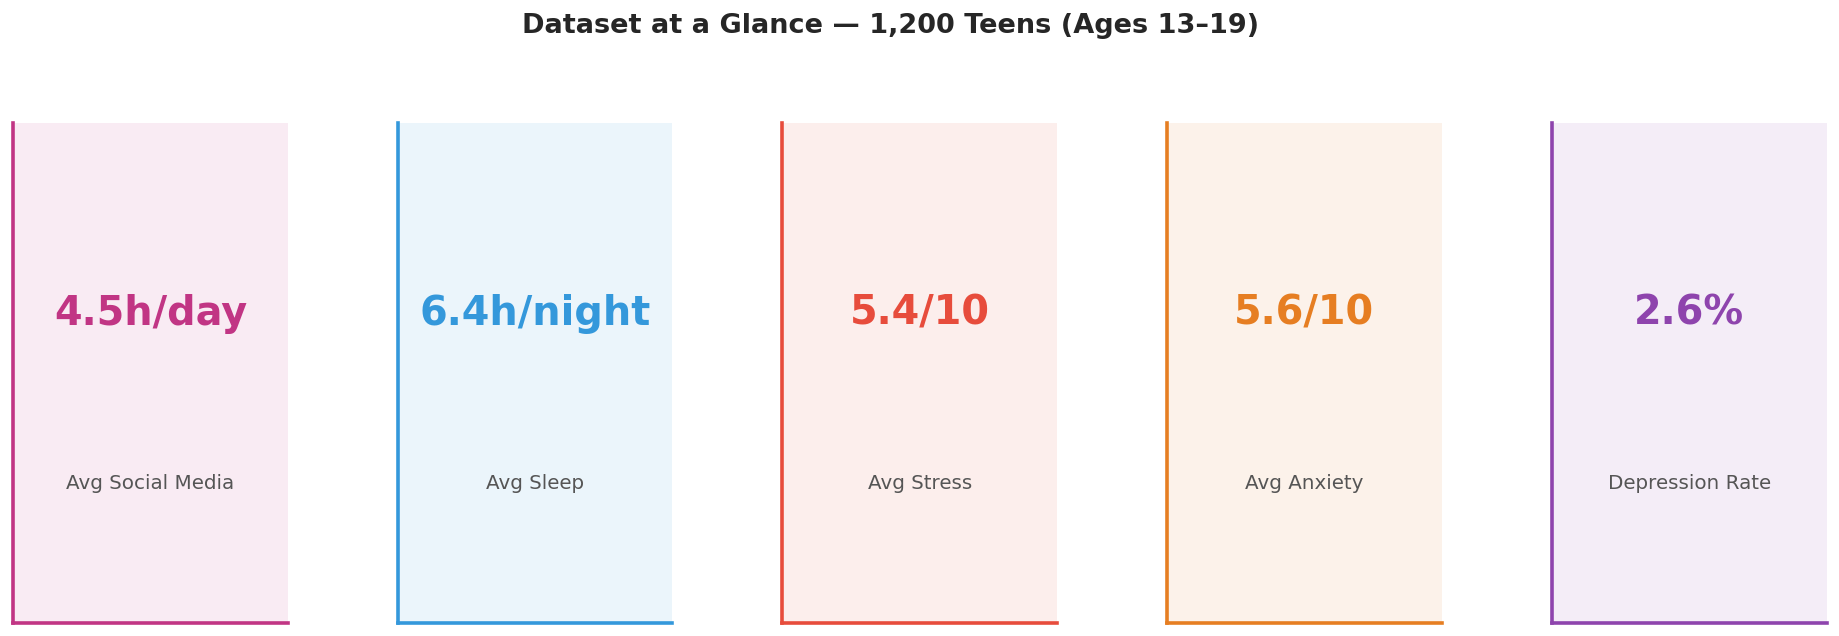

In [4]:
# ── Quick snapshot dashboard ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 5))
gs  = gridspec.GridSpec(1, 5, figure=fig, wspace=0.4)

metrics = [
    ('Avg Social Media', f"{df['daily_social_media_hours'].mean():.1f}h/day", '#C13584'),
    ('Avg Sleep',        f"{df['sleep_hours'].mean():.1f}h/night",            '#3498db'),
    ('Avg Stress',       f"{df['stress_level'].mean():.1f}/10",               '#e74c3c'),
    ('Avg Anxiety',      f"{df['anxiety_level'].mean():.1f}/10",              '#e67e22'),
    ('Depression Rate',  f"{df['depression_label'].mean()*100:.1f}%",         '#8e44ad'),
]

for i, (label, val, color) in enumerate(metrics):
    ax = fig.add_subplot(gs[i])
    ax.set_facecolor(color + '18')
    ax.text(0.5, 0.62, val, ha='center', va='center', fontsize=22,
            fontweight='bold', color=color, transform=ax.transAxes)
    ax.text(0.5, 0.28, label, ha='center', va='center', fontsize=11,
            color='#555', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_edgecolor(color); spine.set_linewidth(2)

fig.suptitle('Dataset at a Glance — 1,200 Teens (Ages 13–19)', fontsize=15, fontweight='bold', y=1.05)
plt.show()

---
<a id='3'></a>
## 3 — Demographic Analysis

> **Visualizations used:** Bar chart, Pie chart, Grouped bar chart, Count plot
>
> **Why:** Categorical distributions are best shown with bar/count plots; proportions with pie/donut charts.

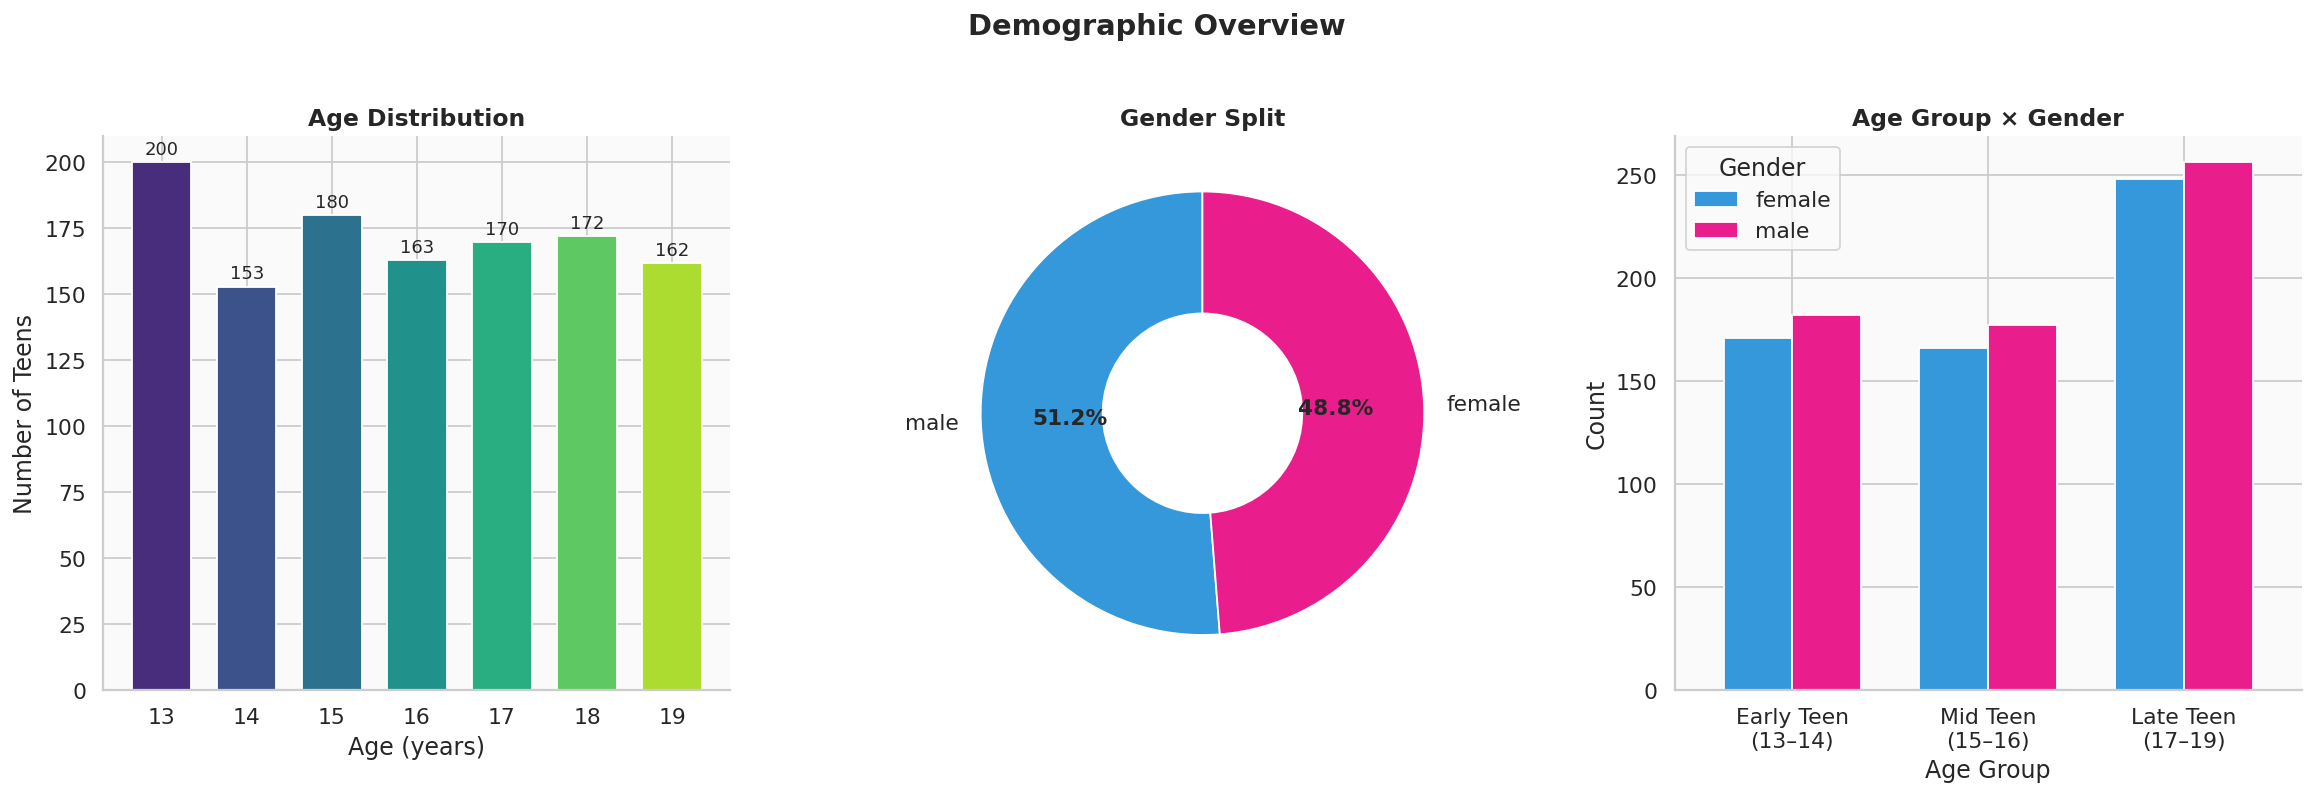

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# ── Age distribution ──────────────────────────────────────────────────────────
age_counts = df['age'].value_counts().sort_index()
axes[0].bar(age_counts.index, age_counts.values,
            color=sns.color_palette('viridis', len(age_counts)), edgecolor='white', width=0.7)
axes[0].set_title('Age Distribution', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Teens')
for x, y in zip(age_counts.index, age_counts.values):
    axes[0].text(x, y + 3, str(y), ha='center', fontsize=10)

# ── Gender donut chart ────────────────────────────────────────────────────────
gender_counts = df['gender'].value_counts()
colors_g = [PAL_GENDER[g] for g in gender_counts.index]
wedges, texts, autotexts = axes[1].pie(
    gender_counts.values, labels=gender_counts.index,
    autopct='%1.1f%%', colors=colors_g,
    wedgeprops={'width': 0.55}, startangle=90,
    textprops={'fontsize': 12})
for at in autotexts: at.set_fontweight('bold')
axes[1].set_title('Gender Split', fontweight='bold', fontsize=13)

# ── Age group × Gender grouped bar ───────────────────────────────────────────
ag_gender = df.groupby(['age_group', 'gender'], observed=True).size().unstack()
ag_gender.plot(kind='bar', ax=axes[2], color=[PAL_GENDER['male'], PAL_GENDER['female']],
               edgecolor='white', width=0.7)
axes[2].set_title('Age Group × Gender', fontweight='bold', fontsize=13)
axes[2].set_xlabel('Age Group')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Gender')

plt.suptitle('Demographic Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
<a id='4'></a>
## 4 — Social Media & Platform Usage

> **Visualizations used:** Histogram with KDE, Violin plot, Stacked bar chart, Strip plot
>
> **Why:** Continuous distributions need histograms/KDE; platform comparisons benefit from violin plots showing full distribution shape.

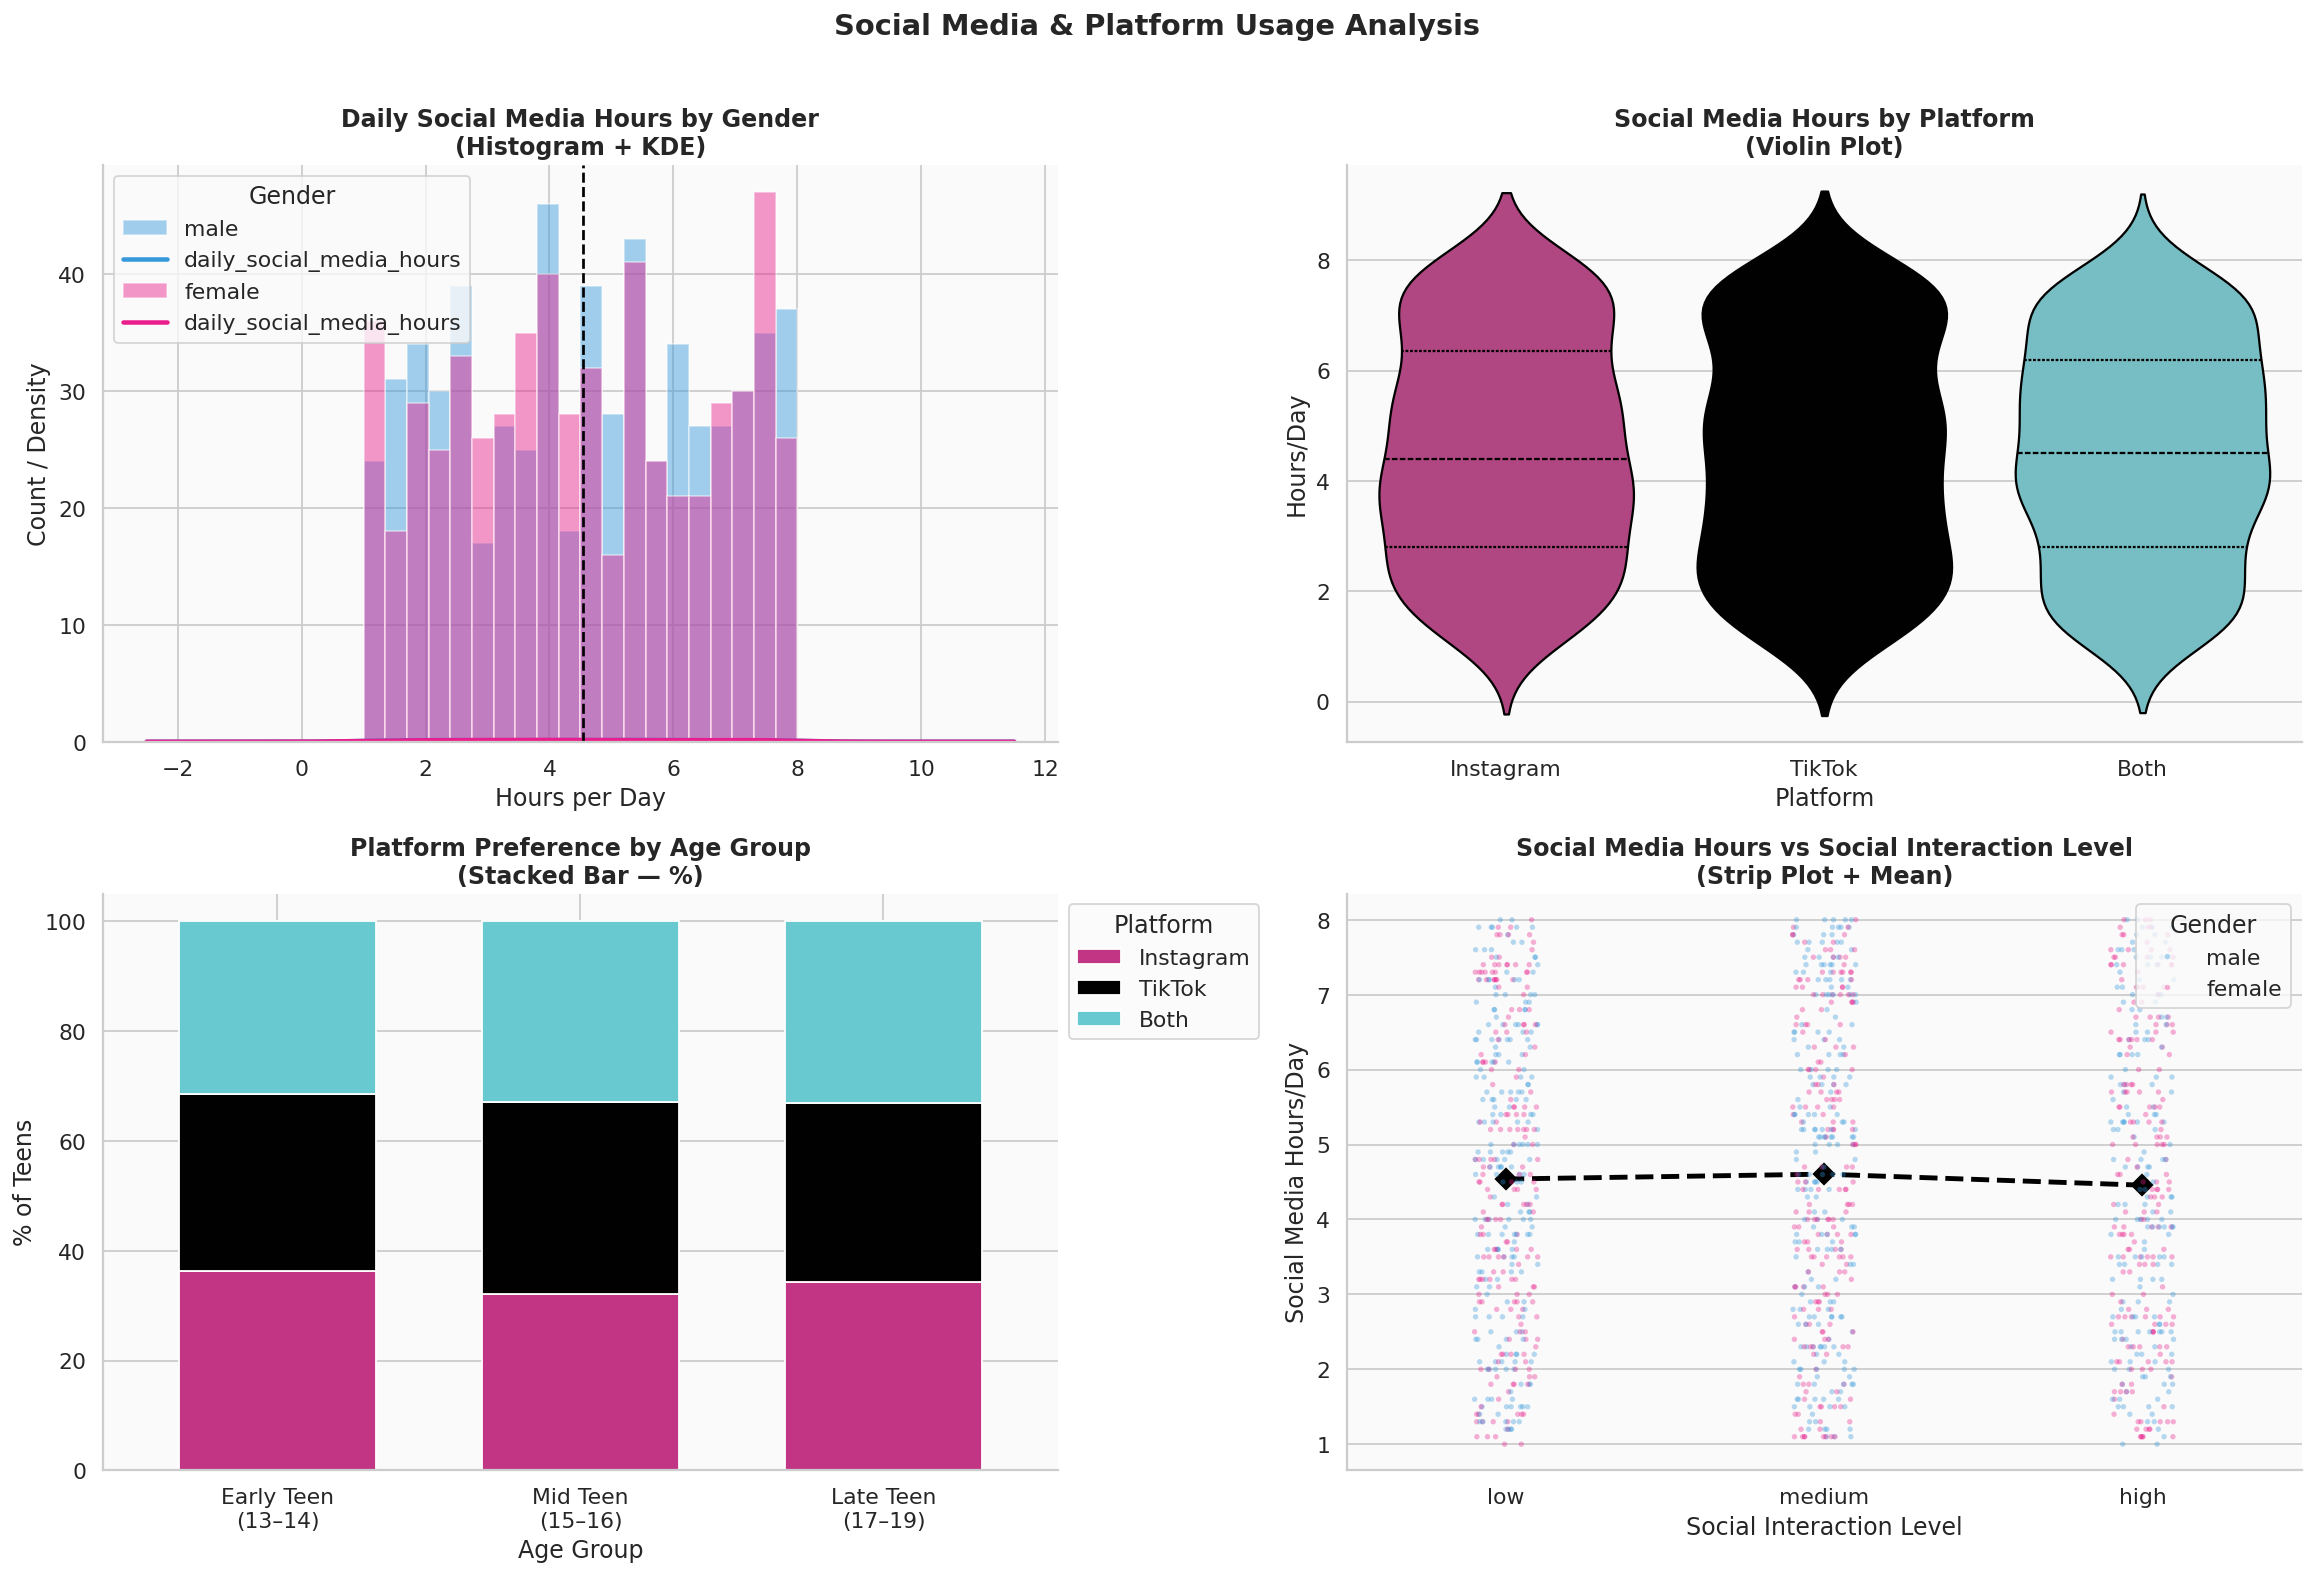

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Histogram + KDE: Daily social media hours ─────────────────────────────────
for gender, color in PAL_GENDER.items():
    subset = df[df['gender'] == gender]['daily_social_media_hours']
    axes[0,0].hist(subset, bins=20, alpha=0.45, color=color, label=gender, edgecolor='white')
    subset.plot.kde(ax=axes[0,0], color=color, lw=2.5)
axes[0,0].set_title('Daily Social Media Hours by Gender\n(Histogram + KDE)', fontweight='bold')
axes[0,0].set_xlabel('Hours per Day')
axes[0,0].set_ylabel('Count / Density')
axes[0,0].legend(title='Gender')
axes[0,0].axvline(df['daily_social_media_hours'].mean(), color='black',
                   lw=1.5, linestyle='--', label=f"Mean={df['daily_social_media_hours'].mean():.1f}h")

# ── Violin plot: Social media hours by platform ───────────────────────────────
platform_order = ['Instagram', 'TikTok', 'Both']
sns.violinplot(data=df, x='platform_usage', y='daily_social_media_hours',
               order=platform_order, palette=PAL_PLAT,
               inner='quartile', ax=axes[0,1])
axes[0,1].set_title('Social Media Hours by Platform\n(Violin Plot)', fontweight='bold')
axes[0,1].set_xlabel('Platform')
axes[0,1].set_ylabel('Hours/Day')

# ── Stacked bar: Platform usage by age group ──────────────────────────────────
plat_age = df.groupby(['age_group', 'platform_usage'], observed=True).size().unstack(fill_value=0)
plat_age_pct = plat_age.div(plat_age.sum(axis=1), axis=0) * 100
plat_age_pct[['Instagram','TikTok','Both']].plot(
    kind='bar', stacked=True, ax=axes[1,0],
    color=[PAL_PLAT['Instagram'], PAL_PLAT['TikTok'], PAL_PLAT['Both']],
    edgecolor='white', width=0.65)
axes[1,0].set_title('Platform Preference by Age Group\n(Stacked Bar — %)', fontweight='bold')
axes[1,0].set_ylabel('% of Teens')
axes[1,0].set_xlabel('Age Group')
axes[1,0].tick_params(axis='x', rotation=0)
axes[1,0].legend(title='Platform', bbox_to_anchor=(1, 1))

# ── Strip plot: Social media hours by social interaction level ────────────────
order_sil = ['low', 'medium', 'high']
sns.stripplot(data=df, x='social_interaction_level', y='daily_social_media_hours',
              order=order_sil, hue='gender', palette=PAL_GENDER,
              alpha=0.35, jitter=True, ax=axes[1,1], size=3)
sns.pointplot(data=df, x='social_interaction_level', y='daily_social_media_hours',
              order=order_sil, color='black', markers='D',
              linestyles='--', ax=axes[1,1], errorbar=None)
axes[1,1].set_title('Social Media Hours vs Social Interaction Level\n(Strip Plot + Mean)', fontweight='bold')
axes[1,1].set_xlabel('Social Interaction Level')
axes[1,1].set_ylabel('Social Media Hours/Day')
axes[1,1].legend(title='Gender')

plt.suptitle('Social Media & Platform Usage Analysis', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='5'></a>
## 5 — Sleep & Screen Time Patterns

> **Visualizations used:** Box plot, Scatter plot with regression line, Heatmap (pivot table), KDE plot
>
> **Why:** Box plots reveal outliers and spread; regression scatter shows linear trends; pivot heatmaps encode two categorical dimensions simultaneously.

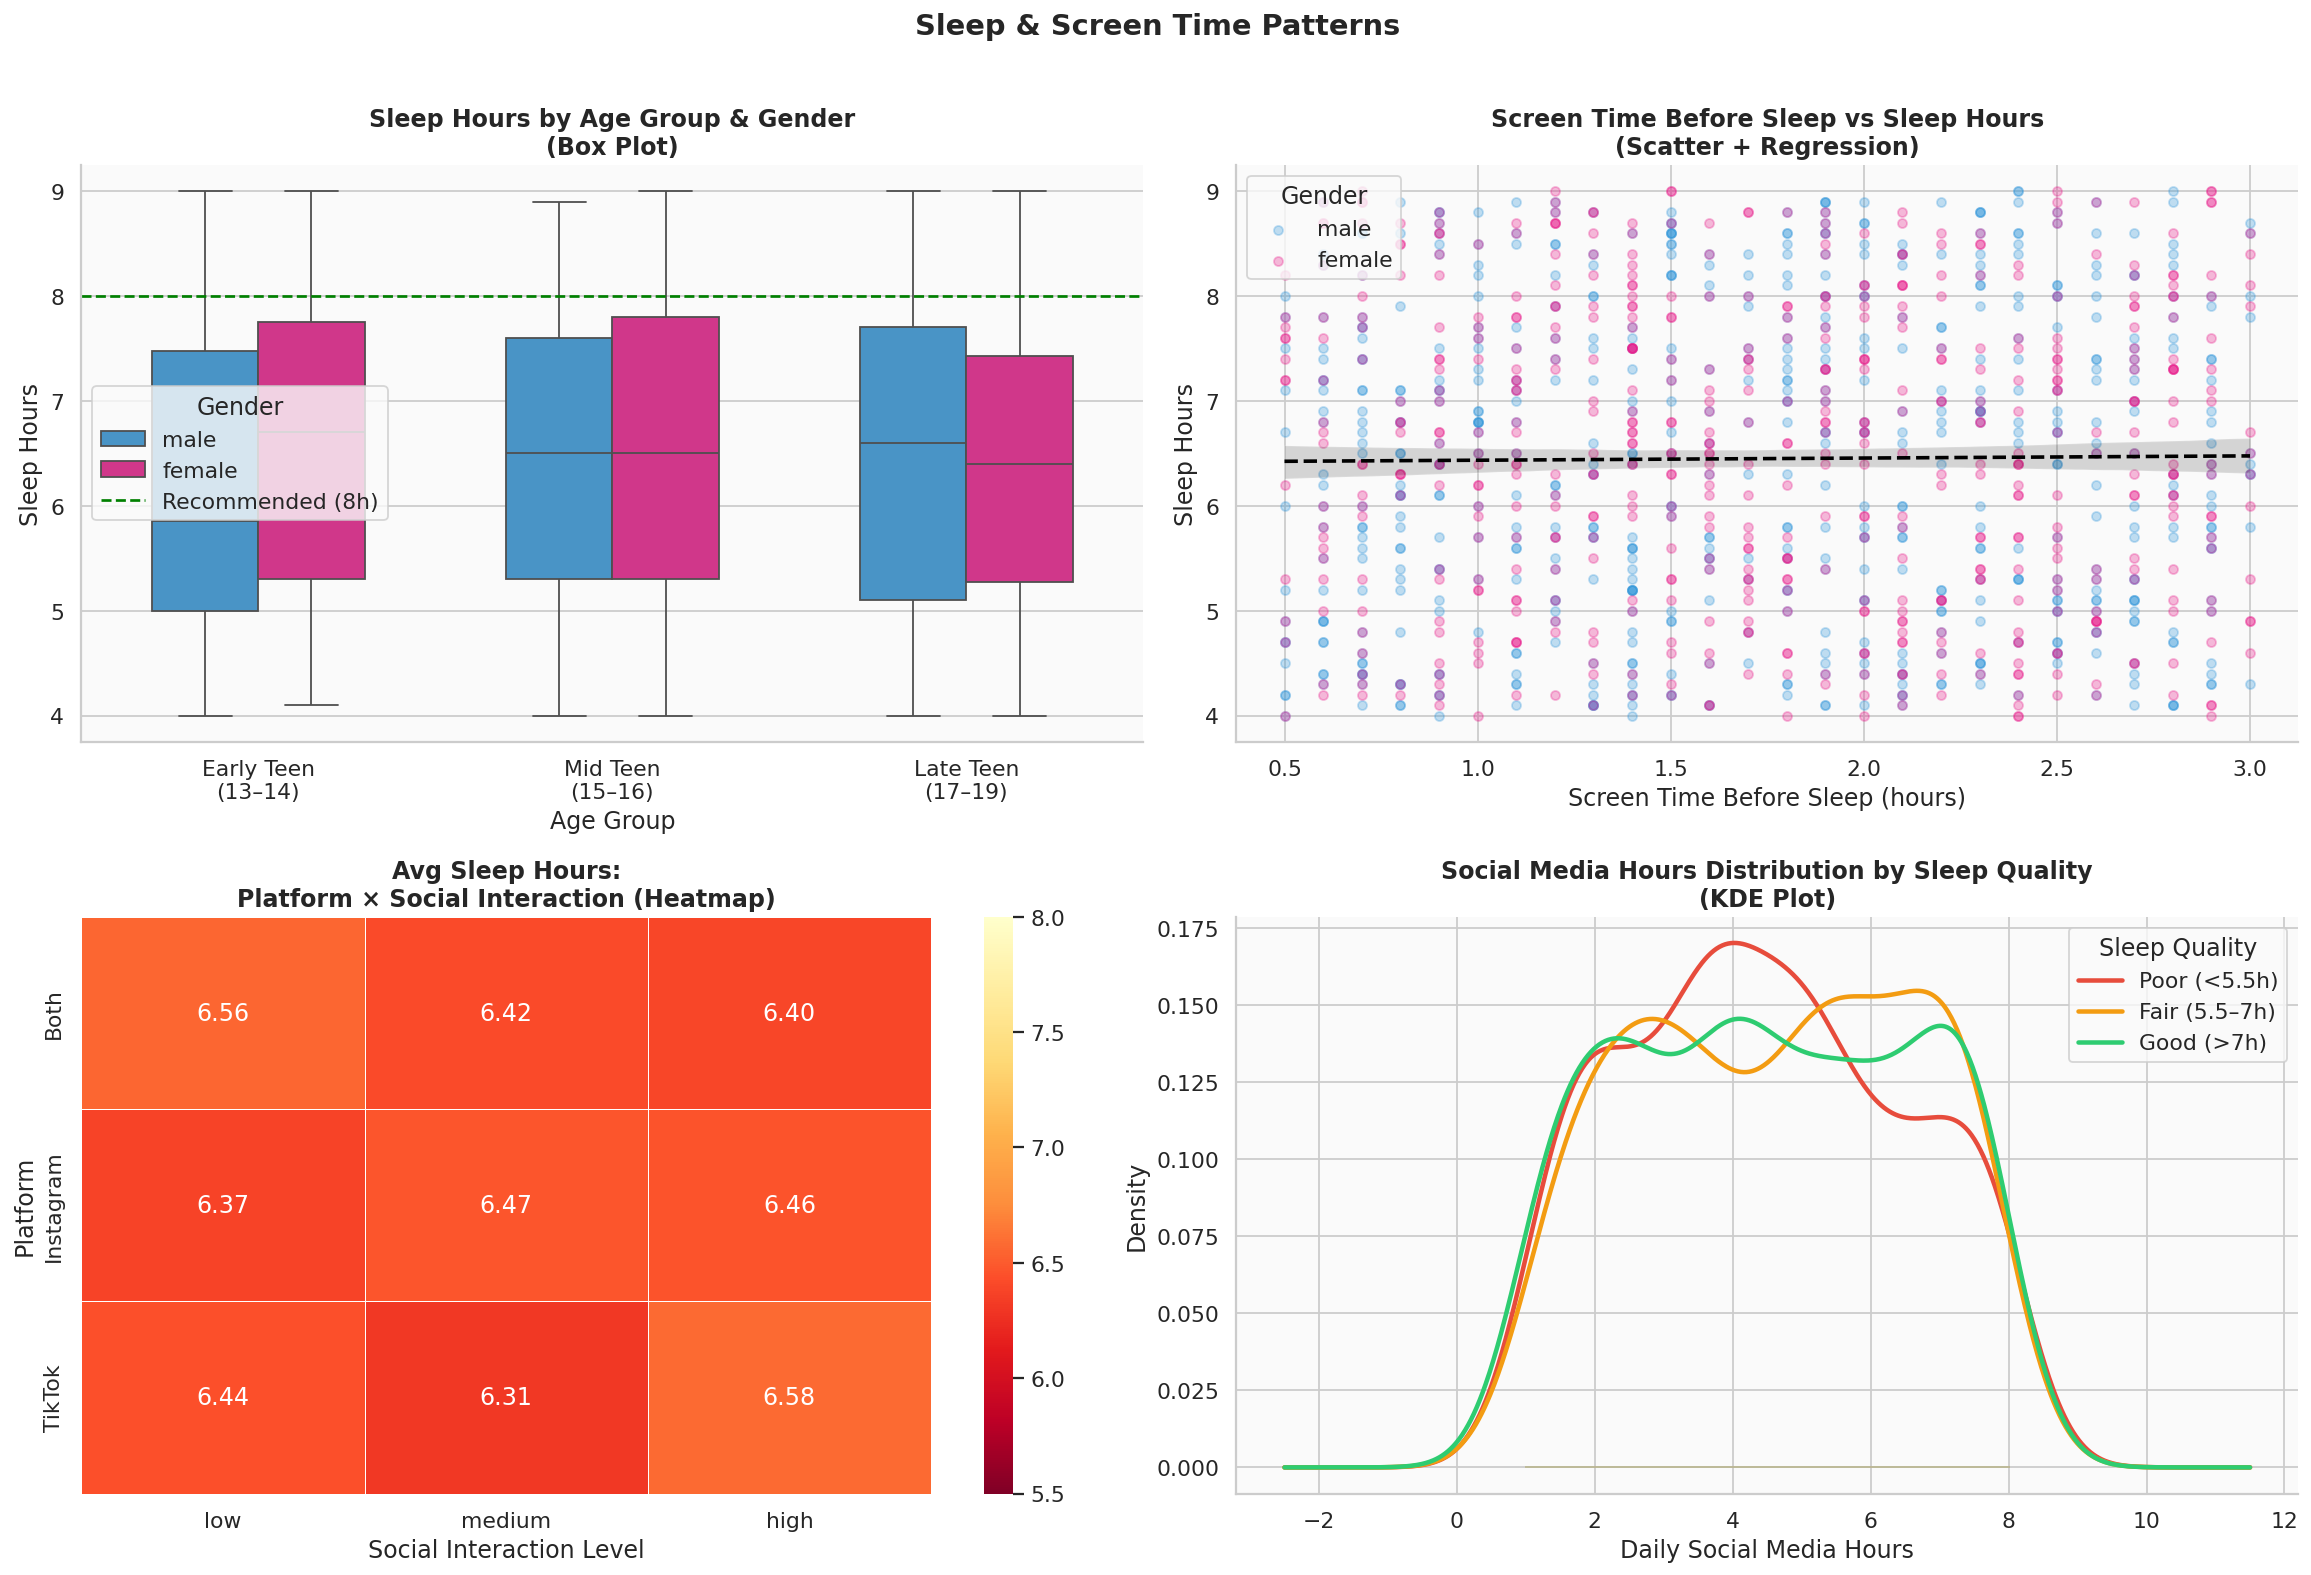

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── Box plot: Sleep hours by age group and gender ─────────────────────────────
sns.boxplot(data=df, x='age_group', y='sleep_hours', hue='gender',
            palette=PAL_GENDER, ax=axes[0,0], width=0.6,
            order=['Early Teen\n(13–14)', 'Mid Teen\n(15–16)', 'Late Teen\n(17–19)'])
axes[0,0].axhline(8, color='green', lw=1.5, linestyle='--', label='Recommended (8h)')
axes[0,0].set_title('Sleep Hours by Age Group & Gender\n(Box Plot)', fontweight='bold')
axes[0,0].set_xlabel('Age Group')
axes[0,0].set_ylabel('Sleep Hours')
axes[0,0].legend(title='Gender')

# ── Scatter + regression: Screen time before sleep vs sleep hours ─────────────
for gender, color in PAL_GENDER.items():
    subset = df[df['gender'] == gender]
    axes[0,1].scatter(subset['screen_time_before_sleep'], subset['sleep_hours'],
                      alpha=0.3, color=color, label=gender, s=25)
sns.regplot(data=df, x='screen_time_before_sleep', y='sleep_hours',
            scatter=False, color='black', line_kws={'lw': 2, 'linestyle': '--'}, ax=axes[0,1])
axes[0,1].set_title('Screen Time Before Sleep vs Sleep Hours\n(Scatter + Regression)', fontweight='bold')
axes[0,1].set_xlabel('Screen Time Before Sleep (hours)')
axes[0,1].set_ylabel('Sleep Hours')
axes[0,1].legend(title='Gender')

# ── Pivot heatmap: Avg sleep hours by platform and social interaction ──────────
pivot_sleep = df.pivot_table(values='sleep_hours',
                              index='platform_usage',
                              columns='social_interaction_level',
                              aggfunc='mean')[['low','medium','high']]
sns.heatmap(pivot_sleep, annot=True, fmt='.2f', cmap='YlOrRd_r',
            linewidths=0.5, ax=axes[1,0], vmin=5.5, vmax=8)
axes[1,0].set_title('Avg Sleep Hours:\nPlatform × Social Interaction (Heatmap)', fontweight='bold')
axes[1,0].set_xlabel('Social Interaction Level')
axes[1,0].set_ylabel('Platform')

# ── KDE: Sleep hours by sleep quality category ────────────────────────────────
colors_sq = ['#e74c3c', '#f39c12', '#2ecc71']
for sq, color in zip(['Poor (<5.5h)', 'Fair (5.5–7h)', 'Good (>7h)'], colors_sq):
    subset = df[df['sleep_quality'] == sq]['daily_social_media_hours']
    if len(subset) > 1:
        subset.plot.kde(ax=axes[1,1], label=sq, color=color, lw=2.5)
        axes[1,1].fill_between(
            np.linspace(subset.min(), subset.max(), 100),
            0, 0, alpha=0.15, color=color)
axes[1,1].set_title('Social Media Hours Distribution by Sleep Quality\n(KDE Plot)', fontweight='bold')
axes[1,1].set_xlabel('Daily Social Media Hours')
axes[1,1].set_ylabel('Density')
axes[1,1].legend(title='Sleep Quality')

plt.suptitle('Sleep & Screen Time Patterns', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='6'></a>
## 6 — Mental Health Indicators

> **Visualizations used:** Radar chart, Ridge plot (stacked KDE), Grouped bar chart, Bubble chart
>
> **Why:** Radar charts compare multi-dimensional scores holistically; ridge plots elegantly show distribution shifts across groups.

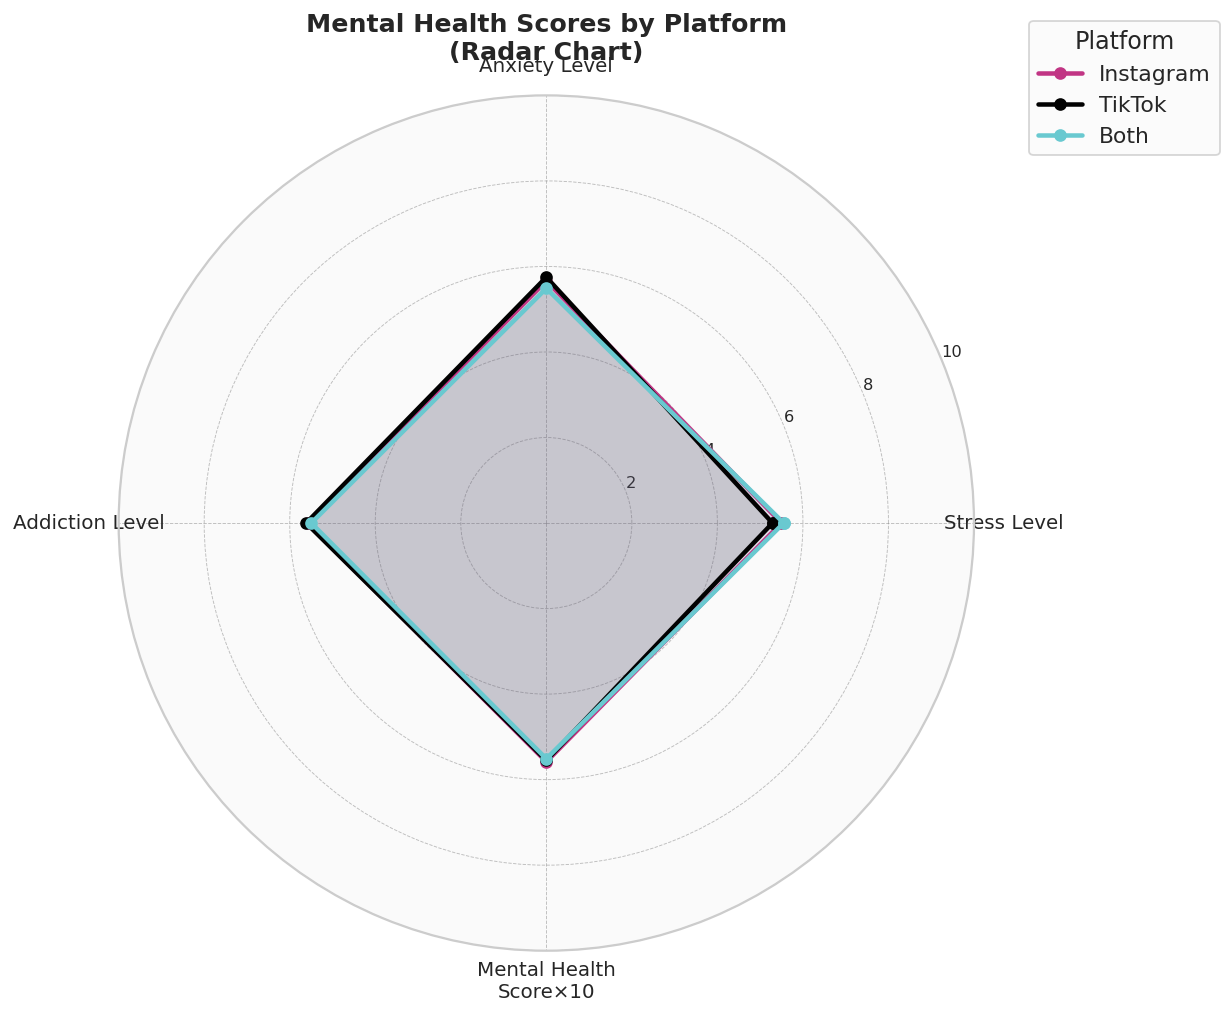

In [8]:
# ── Radar chart: Avg mental health scores by platform ────────────────────────
from matplotlib.patches import FancyArrowPatch

categories = ['Stress Level', 'Anxiety Level', 'Addiction Level', 'Mental Health\nScore×10']
platforms  = ['Instagram', 'TikTok', 'Both']
colors_rad = [PAL_PLAT['Instagram'], PAL_PLAT['TikTok'], PAL_PLAT['Both']]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))

angles = np.linspace(0, 2*np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

for plat, color in zip(platforms, colors_rad):
    sub = df[df['platform_usage'] == plat]
    vals = [
        sub['stress_level'].mean(),
        sub['anxiety_level'].mean(),
        sub['addiction_level'].mean(),
        sub['mental_health_score'].mean() * 10 / 10
    ]
    vals += vals[:1]
    ax.plot(angles, vals, 'o-', lw=2.5, color=color, label=plat)
    ax.fill(angles, vals, alpha=0.12, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 10)
ax.set_yticks([2, 4, 6, 8, 10])
ax.set_yticklabels(['2','4','6','8','10'], size=9)
ax.set_title('Mental Health Scores by Platform\n(Radar Chart)', fontweight='bold', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title='Platform')
ax.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()

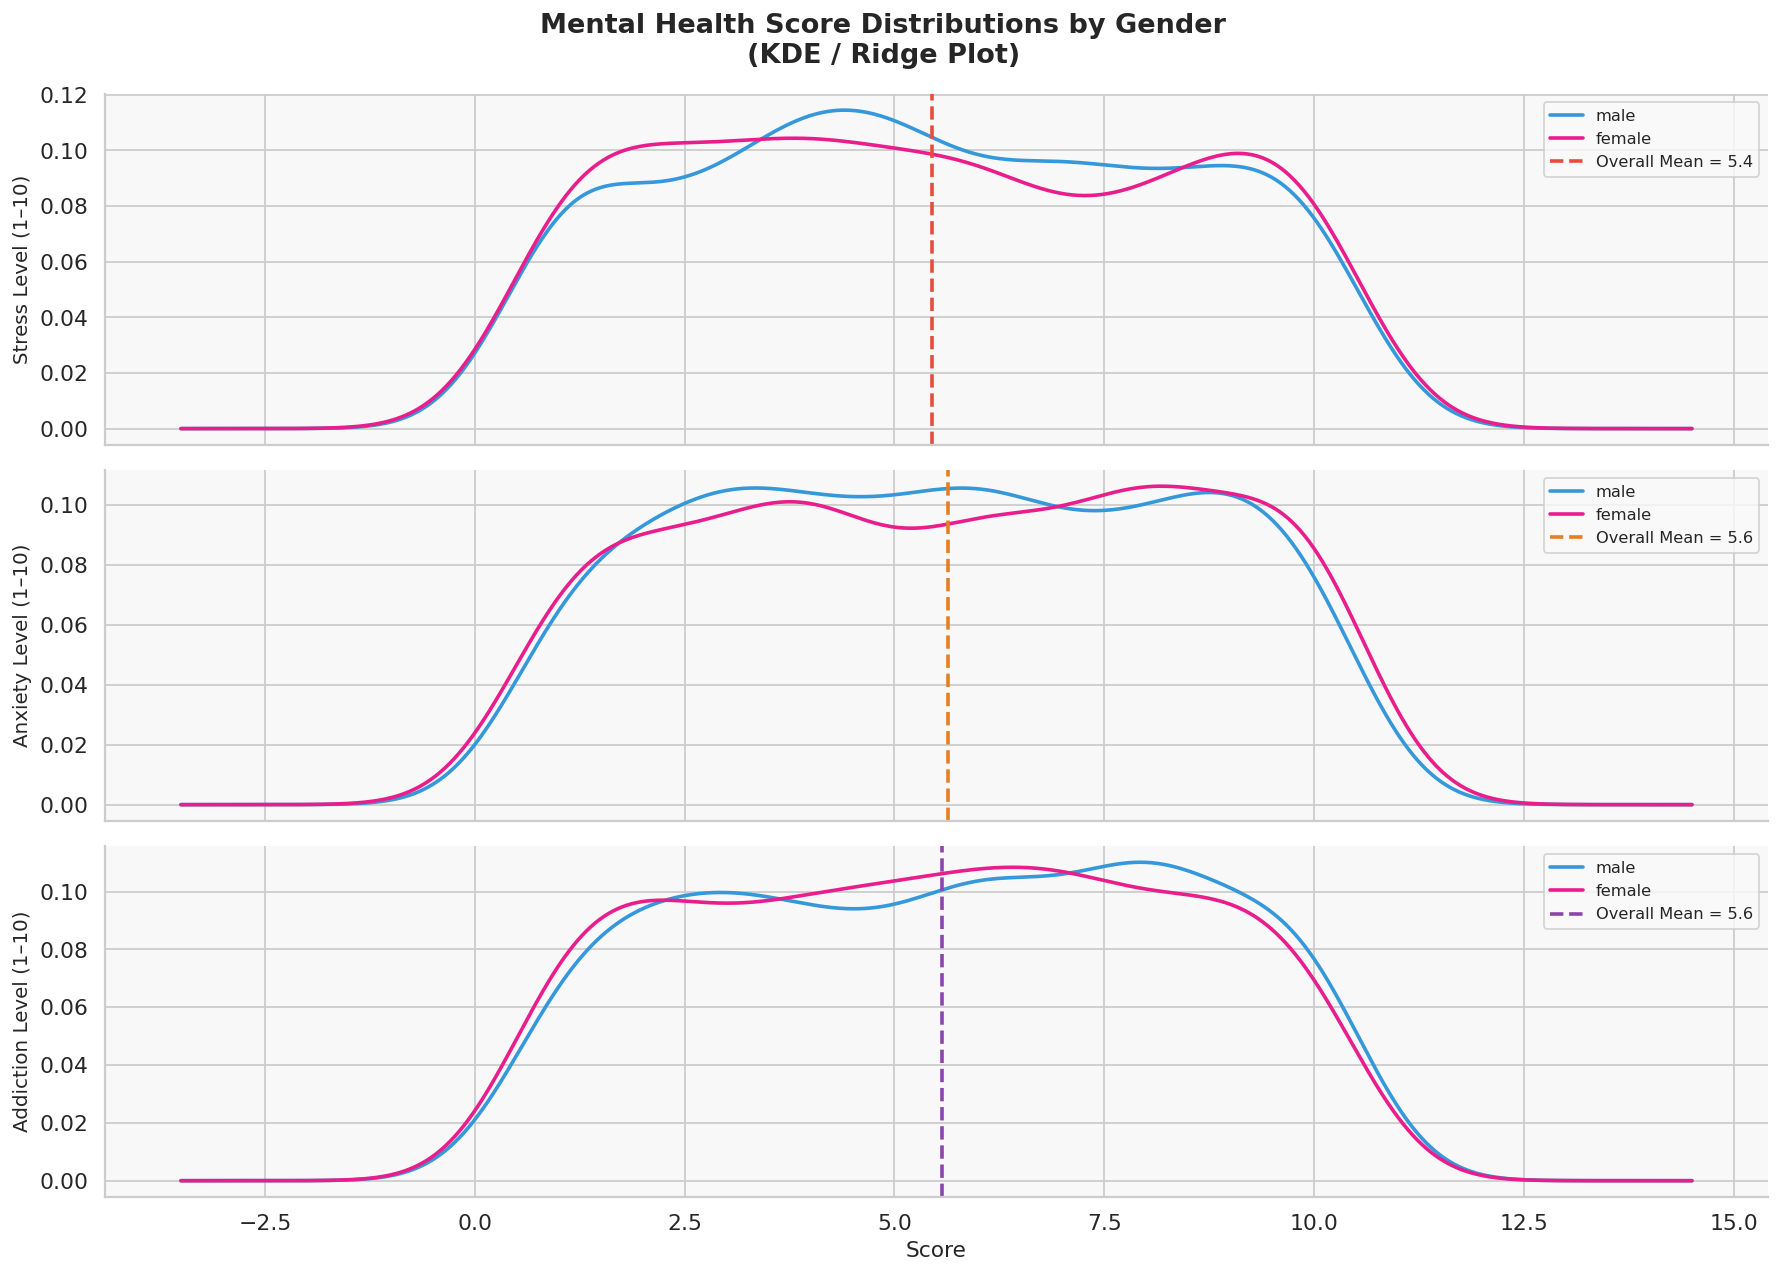

In [9]:
# ── Ridge plot: Distribution of stress / anxiety / addiction ──────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

metrics_ridge = [
    ('stress_level',   'Stress Level (1–10)',   '#e74c3c'),
    ('anxiety_level',  'Anxiety Level (1–10)',  '#e67e22'),
    ('addiction_level','Addiction Level (1–10)','#8e44ad'),
]

for ax, (col, label, color) in zip(axes, metrics_ridge):
    for gender, alpha in [('male', 0.45), ('female', 0.45)]:
        sub = df[df['gender'] == gender][col]
        sub.plot.kde(ax=ax, color=PAL_GENDER[gender], lw=2, label=gender)
        x_vals = np.linspace(sub.min(), sub.max(), 200)
    ax.set_ylabel(label, fontsize=11)
    ax.axvline(df[col].mean(), color=color, lw=2, linestyle='--',
               label=f'Overall Mean = {df[col].mean():.1f}')
    ax.legend(fontsize=9)
    ax.set_facecolor('#f8f8f8')

axes[-1].set_xlabel('Score', fontsize=12)
fig.suptitle('Mental Health Score Distributions by Gender\n(KDE / Ridge Plot)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

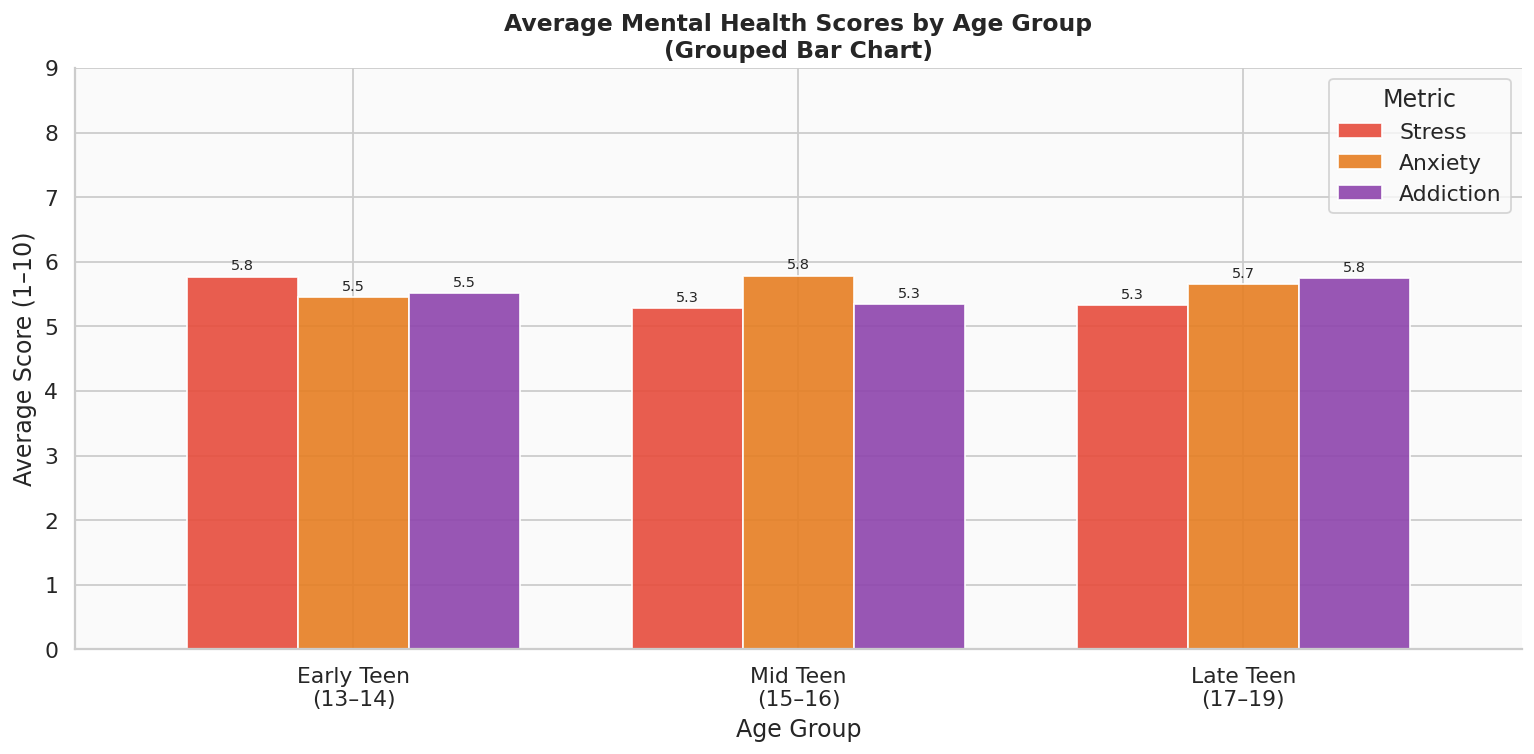

In [10]:
# ── Grouped bar: Mean mental health scores by age group ───────────────────────
age_mental = df.groupby('age_group', observed=True)[['stress_level','anxiety_level','addiction_level']].mean()

fig, ax = plt.subplots(figsize=(12, 6))
age_mental.plot(kind='bar', ax=ax,
                color=['#e74c3c', '#e67e22', '#8e44ad'],
                edgecolor='white', width=0.75, alpha=0.9)
ax.set_title('Average Mental Health Scores by Age Group\n(Grouped Bar Chart)', fontweight='bold', fontsize=13)
ax.set_xlabel('Age Group')
ax.set_ylabel('Average Score (1–10)')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Metric', labels=['Stress', 'Anxiety', 'Addiction'])
ax.set_ylim(0, 9)
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f', fontsize=8, padding=2)
plt.tight_layout()
plt.show()

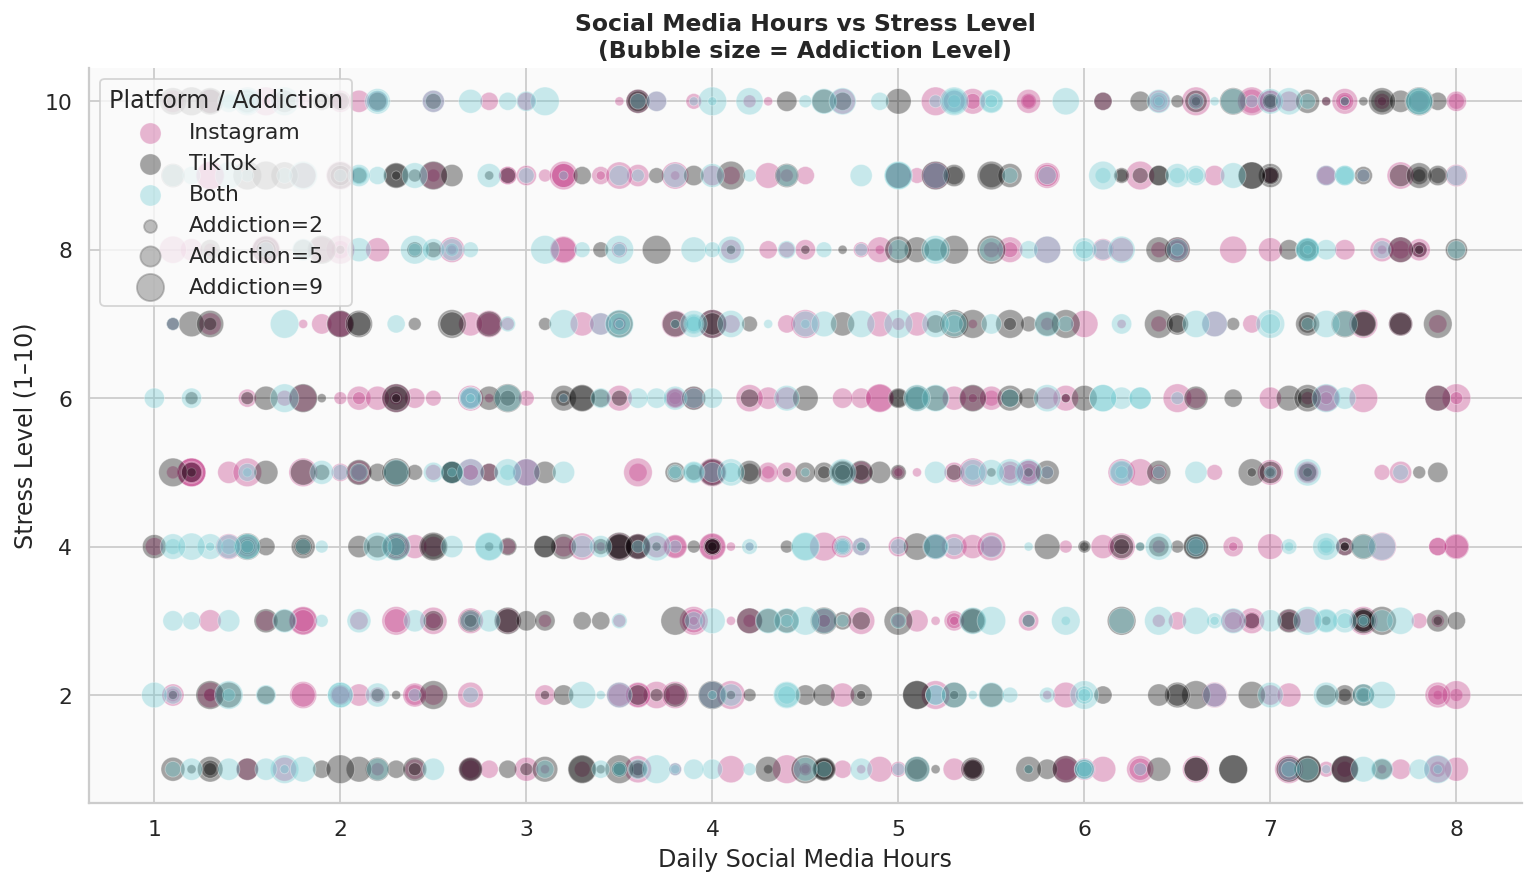

In [11]:
# ── Bubble chart: Social media hours vs stress vs addiction ───────────────────
fig, ax = plt.subplots(figsize=(12, 7))

for plat, color in PAL_PLAT.items():
    sub = df[df['platform_usage'] == plat]
    scatter = ax.scatter(
        sub['daily_social_media_hours'],
        sub['stress_level'],
        s=sub['addiction_level'] * 25,
        c=color, alpha=0.35, label=plat, edgecolors='white', lw=0.5
    )

ax.set_title('Social Media Hours vs Stress Level\n(Bubble size = Addiction Level)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Daily Social Media Hours')
ax.set_ylabel('Stress Level (1–10)')
ax.legend(title='Platform')

# bubble size legend
for size_val in [2, 5, 9]:
    ax.scatter([], [], s=size_val*25, color='grey', alpha=0.5, label=f'Addiction={size_val}')
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, title='Platform / Addiction', scatterpoints=1,
          loc='upper left', framealpha=0.8)

plt.tight_layout()
plt.show()

---
<a id='7'></a>
## 7 — Correlation & Relationship Analysis

> **Visualizations used:** Correlation heatmap, Pair plot, Scatter matrix
>
> **Why:** Heatmaps give a quick overview of all pairwise relationships; pair plots reveal bivariate distributions and clusters simultaneously.

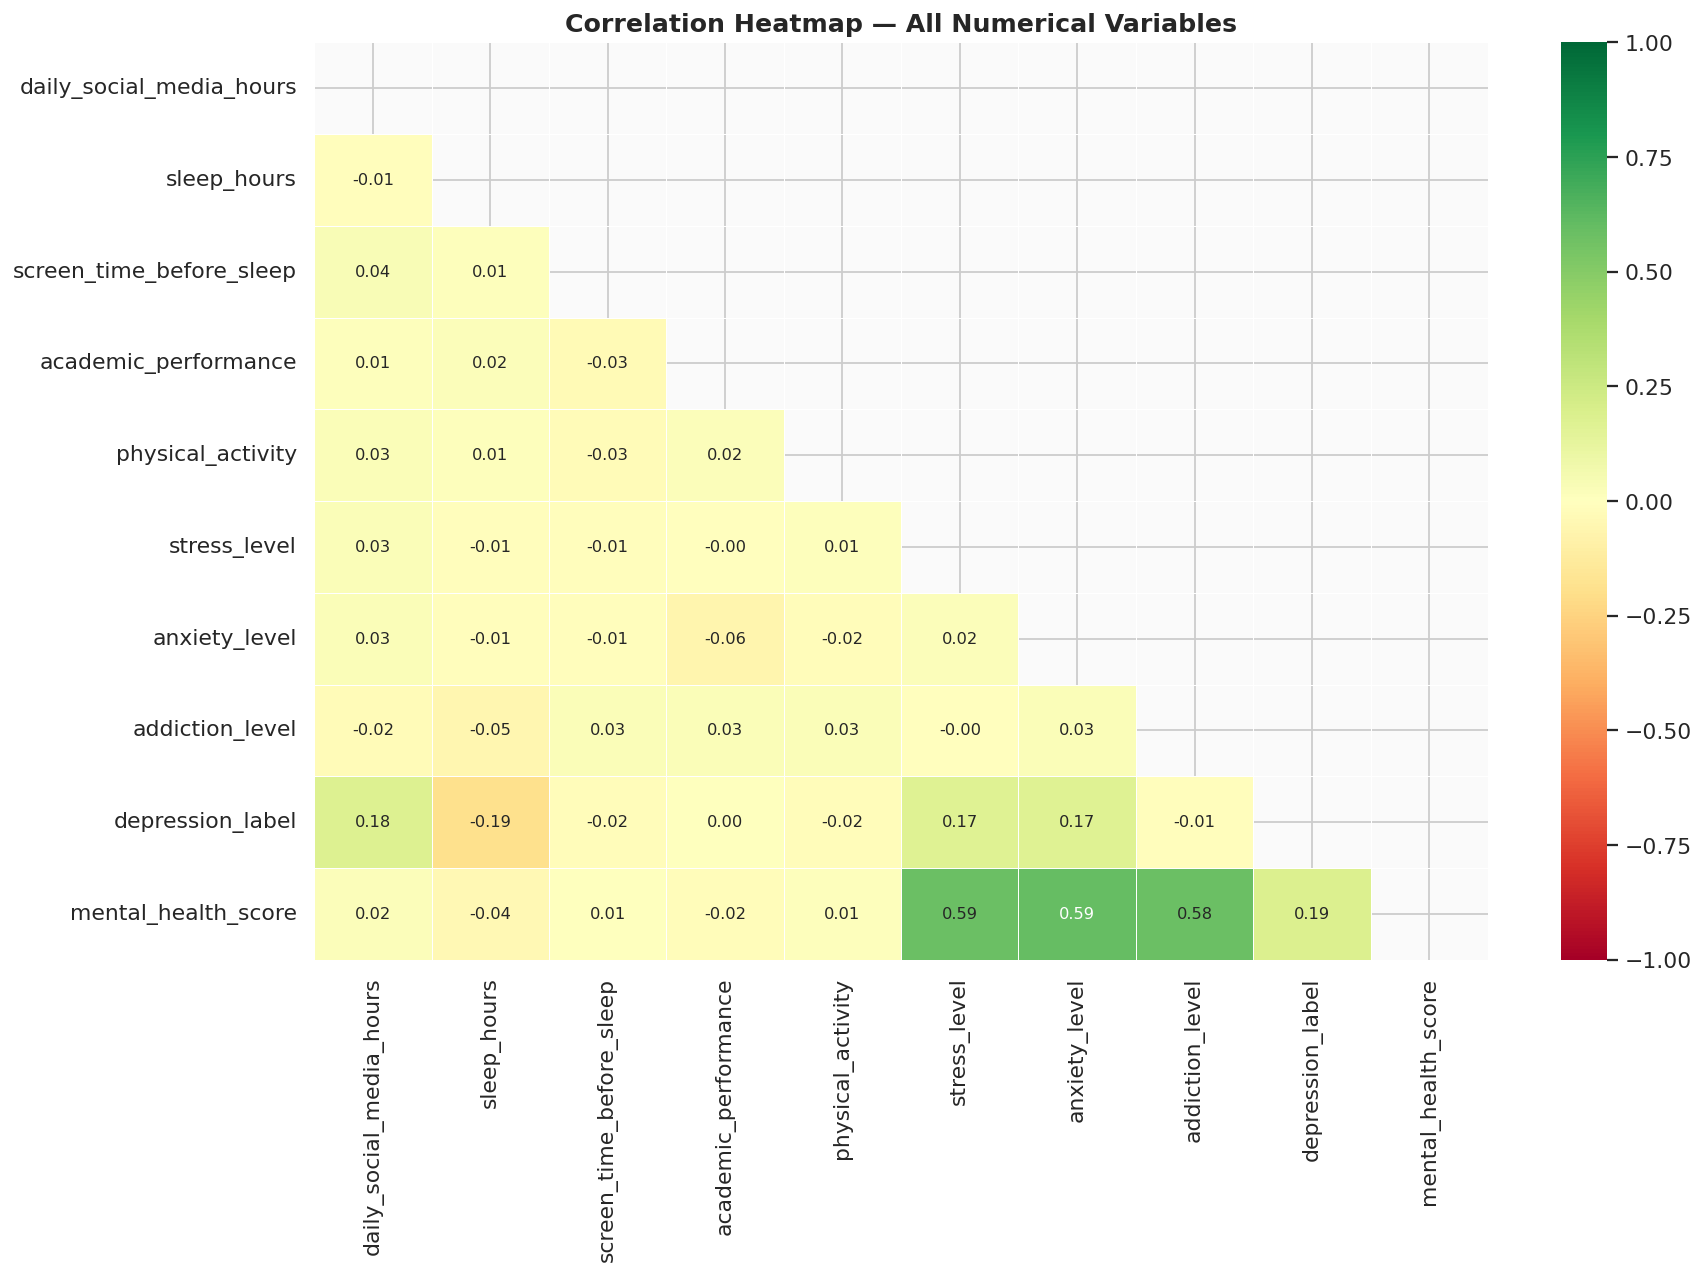

In [12]:
# ── Correlation heatmap ───────────────────────────────────────────────────────
num_cols = ['daily_social_media_hours','sleep_hours','screen_time_before_sleep',
            'academic_performance','physical_activity','stress_level',
            'anxiety_level','addiction_level','depression_label','mental_health_score']

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, linewidths=0.5, ax=ax,
            vmin=-1, vmax=1, center=0,
            annot_kws={'size': 9})
ax.set_title('Correlation Heatmap — All Numerical Variables',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

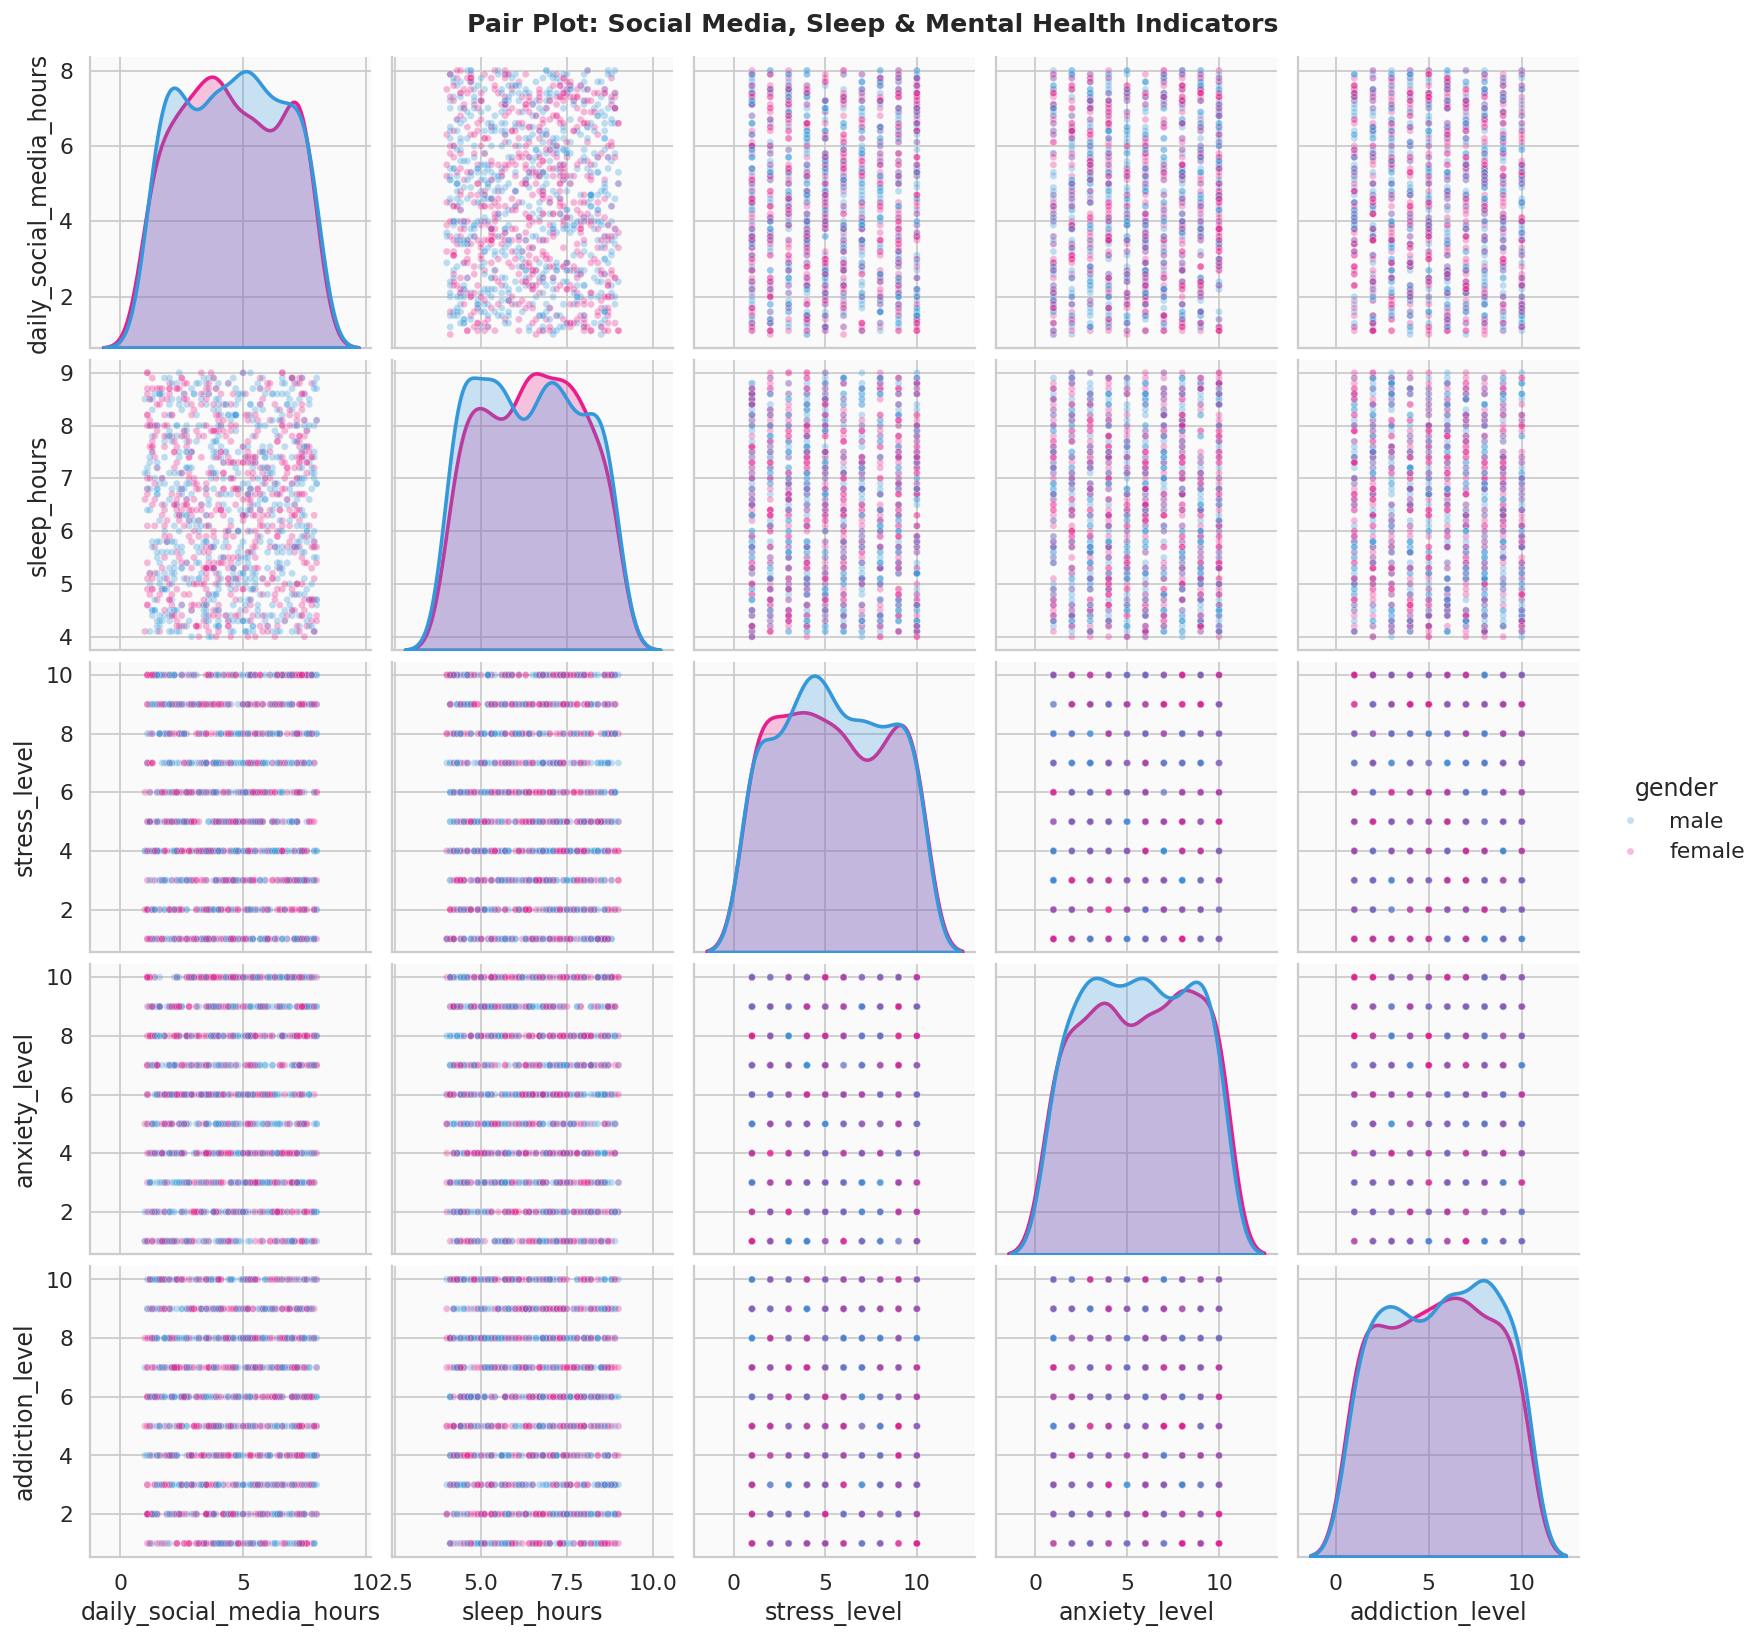

In [13]:
# ── Pair plot: Key mental health variables ────────────────────────────────────
pair_cols = ['daily_social_media_hours','sleep_hours','stress_level',
             'anxiety_level','addiction_level']

g = sns.pairplot(
    df[pair_cols + ['gender']],
    hue='gender',
    palette=PAL_GENDER,
    diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    diag_kws={'lw': 2}
)
g.figure.suptitle('Pair Plot: Social Media, Sleep & Mental Health Indicators',
                   fontsize=14, fontweight='bold', y=1.01)
plt.show()

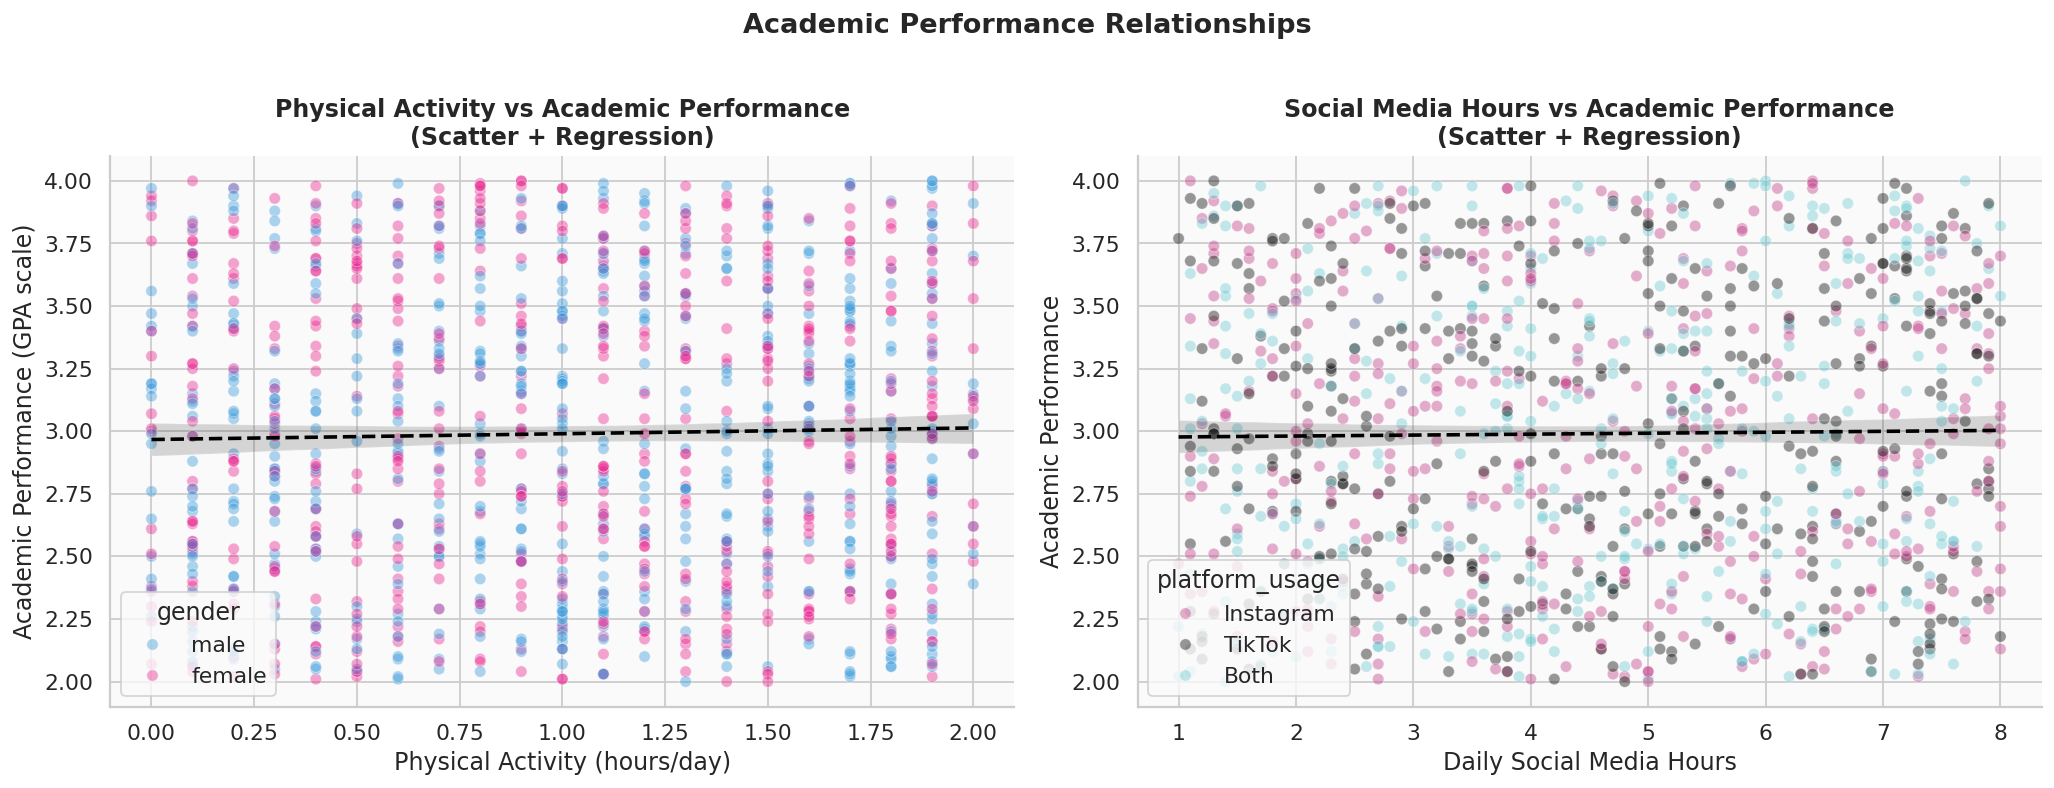

In [14]:
# ── Scatter: Academic performance vs physical activity ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df, x='physical_activity', y='academic_performance',
                hue='gender', palette=PAL_GENDER, alpha=0.4,
                ax=axes[0], s=40)
sns.regplot(data=df, x='physical_activity', y='academic_performance',
            scatter=False, color='black', ax=axes[0], line_kws={'lw':2, 'ls':'--'})
axes[0].set_title('Physical Activity vs Academic Performance\n(Scatter + Regression)', fontweight='bold')
axes[0].set_xlabel('Physical Activity (hours/day)')
axes[0].set_ylabel('Academic Performance (GPA scale)')

sns.scatterplot(data=df, x='daily_social_media_hours', y='academic_performance',
                hue='platform_usage', palette=PAL_PLAT, alpha=0.4,
                ax=axes[1], s=40)
sns.regplot(data=df, x='daily_social_media_hours', y='academic_performance',
            scatter=False, color='black', ax=axes[1], line_kws={'lw':2, 'ls':'--'})
axes[1].set_title('Social Media Hours vs Academic Performance\n(Scatter + Regression)', fontweight='bold')
axes[1].set_xlabel('Daily Social Media Hours')
axes[1].set_ylabel('Academic Performance')

plt.suptitle('Academic Performance Relationships', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='8'></a>
## 8 — Depression Label Deep Dive

> **Visualizations used:** Mosaic-style grouped bar, Horizontal bar chart, Side-by-side box plots, Annotated count plot
>
> **Why:** With a heavily imbalanced label (2.6% positive), we focus on comparing feature distributions between groups rather than raw counts.

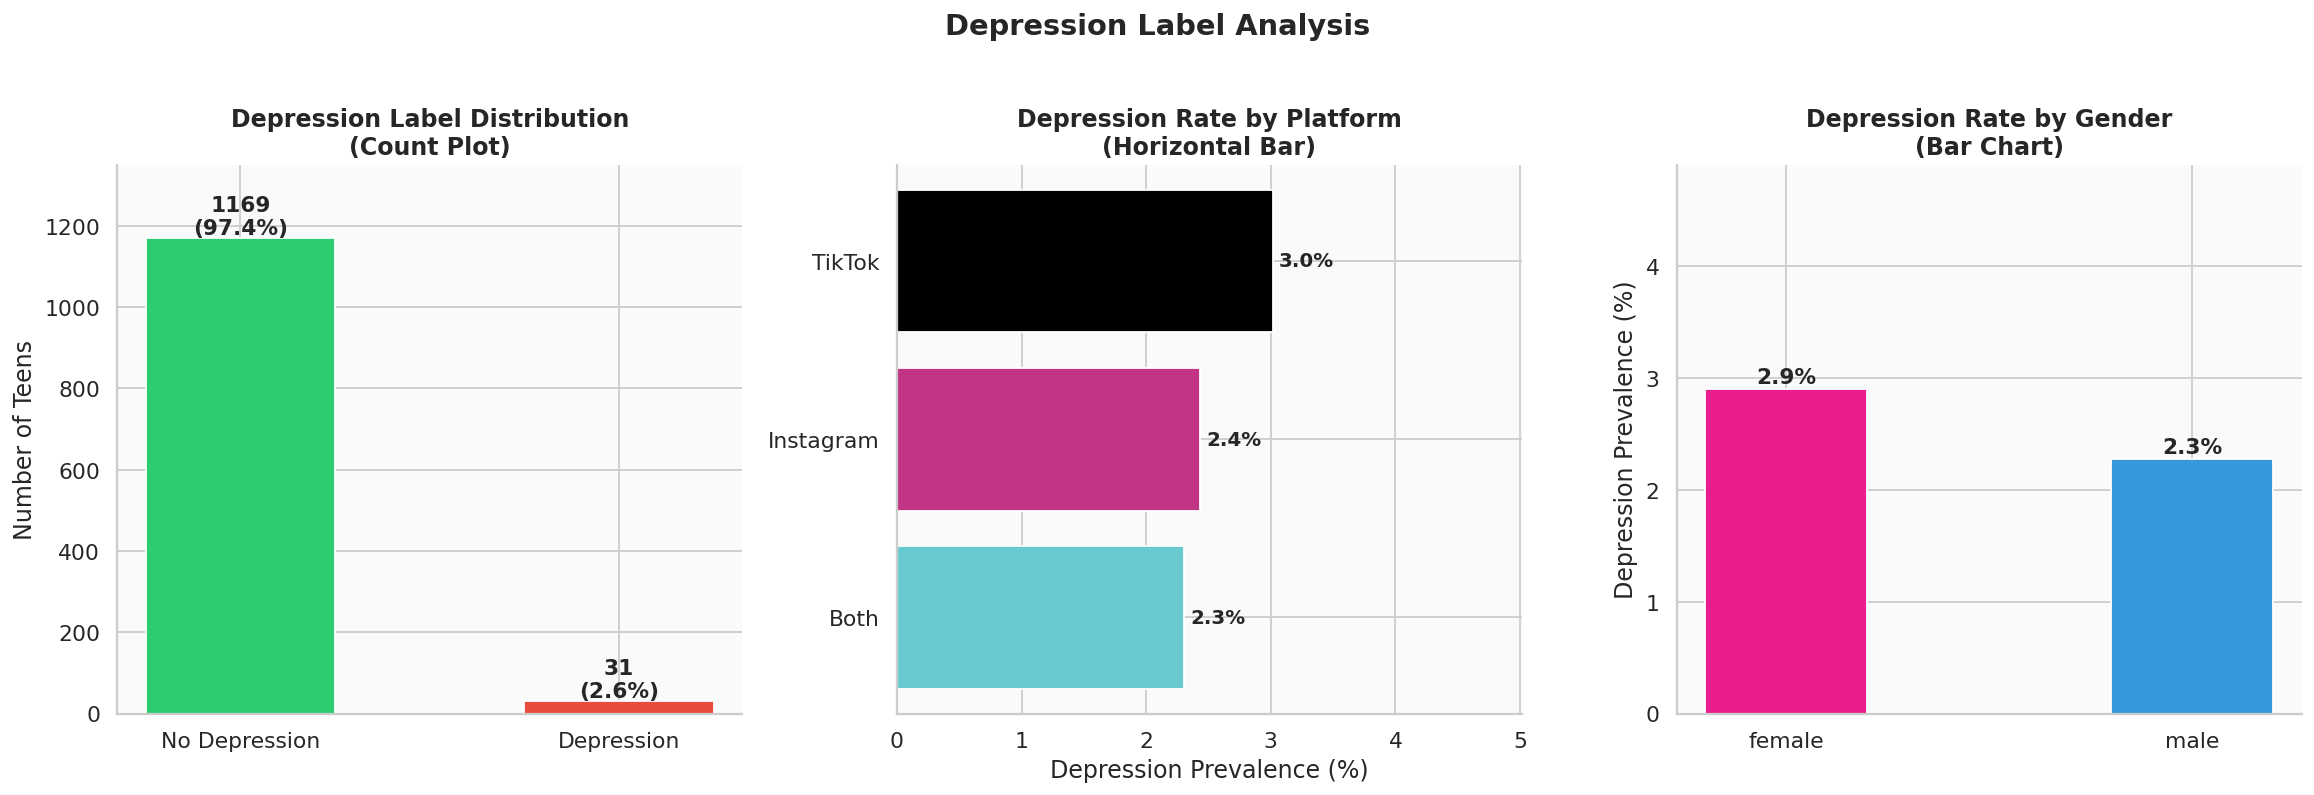

In [15]:
# ── Class imbalance visualization ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Annotated count plot
dep_counts = df['depression_label_str'].value_counts()
bars = axes[0].bar(dep_counts.index, dep_counts.values,
                   color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
for bar, val in zip(bars, dep_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=12, fontweight='bold')
axes[0].set_title('Depression Label Distribution\n(Count Plot)', fontweight='bold')
axes[0].set_ylabel('Number of Teens')
axes[0].set_ylim(0, 1350)

# Depression rate by platform
dep_plat = df.groupby('platform_usage')['depression_label'].mean() * 100
colors_dp = [PAL_PLAT[p] for p in dep_plat.index]
axes[1].barh(dep_plat.index, dep_plat.values, color=colors_dp, edgecolor='white')
for i, val in enumerate(dep_plat.values):
    axes[1].text(val + 0.05, i, f'{val:.1f}%', va='center', fontsize=11, fontweight='bold')
axes[1].set_title('Depression Rate by Platform\n(Horizontal Bar)', fontweight='bold')
axes[1].set_xlabel('Depression Prevalence (%)')
axes[1].set_xlim(0, dep_plat.max() + 2)

# Depression rate by gender
dep_gender = df.groupby('gender')['depression_label'].mean() * 100
bars = axes[2].bar(dep_gender.index,
                   dep_gender.values,
                   color=[PAL_GENDER[g] for g in dep_gender.index],
                   edgecolor='white', width=0.4)
for bar, val in zip(bars, dep_gender.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[2].set_title('Depression Rate by Gender\n(Bar Chart)', fontweight='bold')
axes[2].set_ylabel('Depression Prevalence (%)')
axes[2].set_ylim(0, dep_gender.max() + 2)

plt.suptitle('Depression Label Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

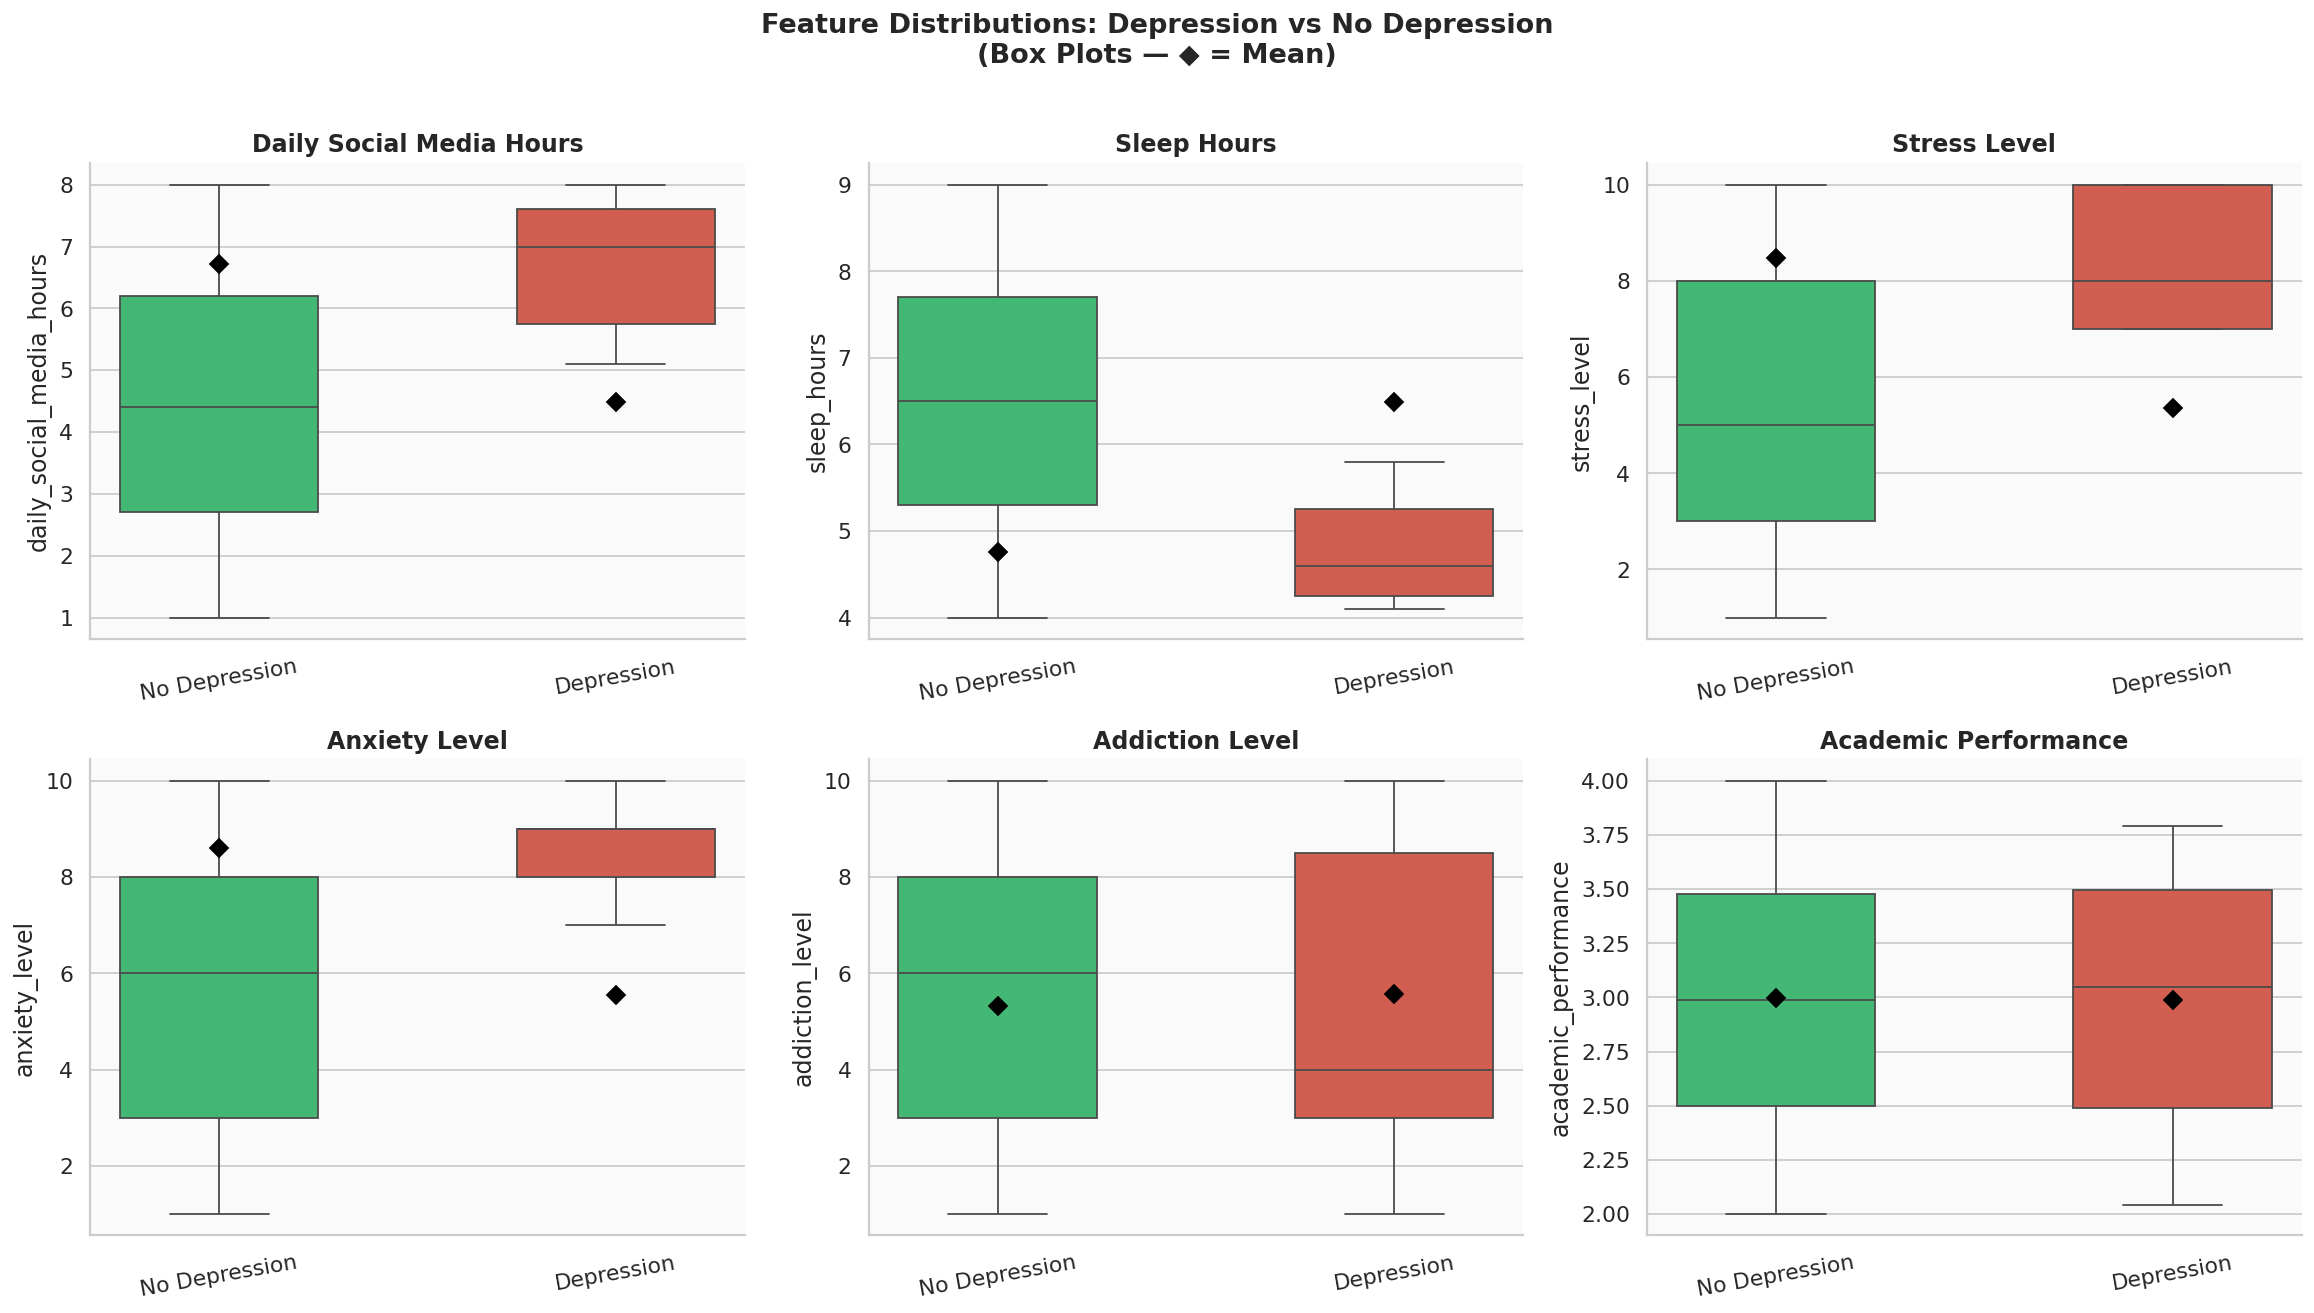

In [16]:
# ── Side-by-side box plots: Feature comparison by depression label ─────────────
compare_cols = ['daily_social_media_hours','sleep_hours','stress_level',
                'anxiety_level','addiction_level','academic_performance']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, col in zip(axes, compare_cols):
    sns.boxplot(data=df, x='depression_label_str', y=col,
                palette={'No Depression': '#2ecc71', 'Depression': '#e74c3c'},
                order=['No Depression', 'Depression'],
                ax=ax, width=0.5)
    # Add mean markers
    means = df.groupby('depression_label_str')[col].mean()
    for j, (label, mean) in enumerate(means.items()):
        ax.plot(j, mean, 'D', color='black', markersize=7, zorder=5)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

plt.suptitle('Feature Distributions: Depression vs No Depression\n(Box Plots — ◆ = Mean)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
<a id='9'></a>
## 9 — Multi-Variable Comparison

> **Visualizations used:** Facet grid, Stacked area chart, Lollipop chart, Annotated heatmap
>
> **Why:** Facet grids allow comparison across two categorical dimensions simultaneously; lollipop charts are a clean alternative to bar charts for ranked data.

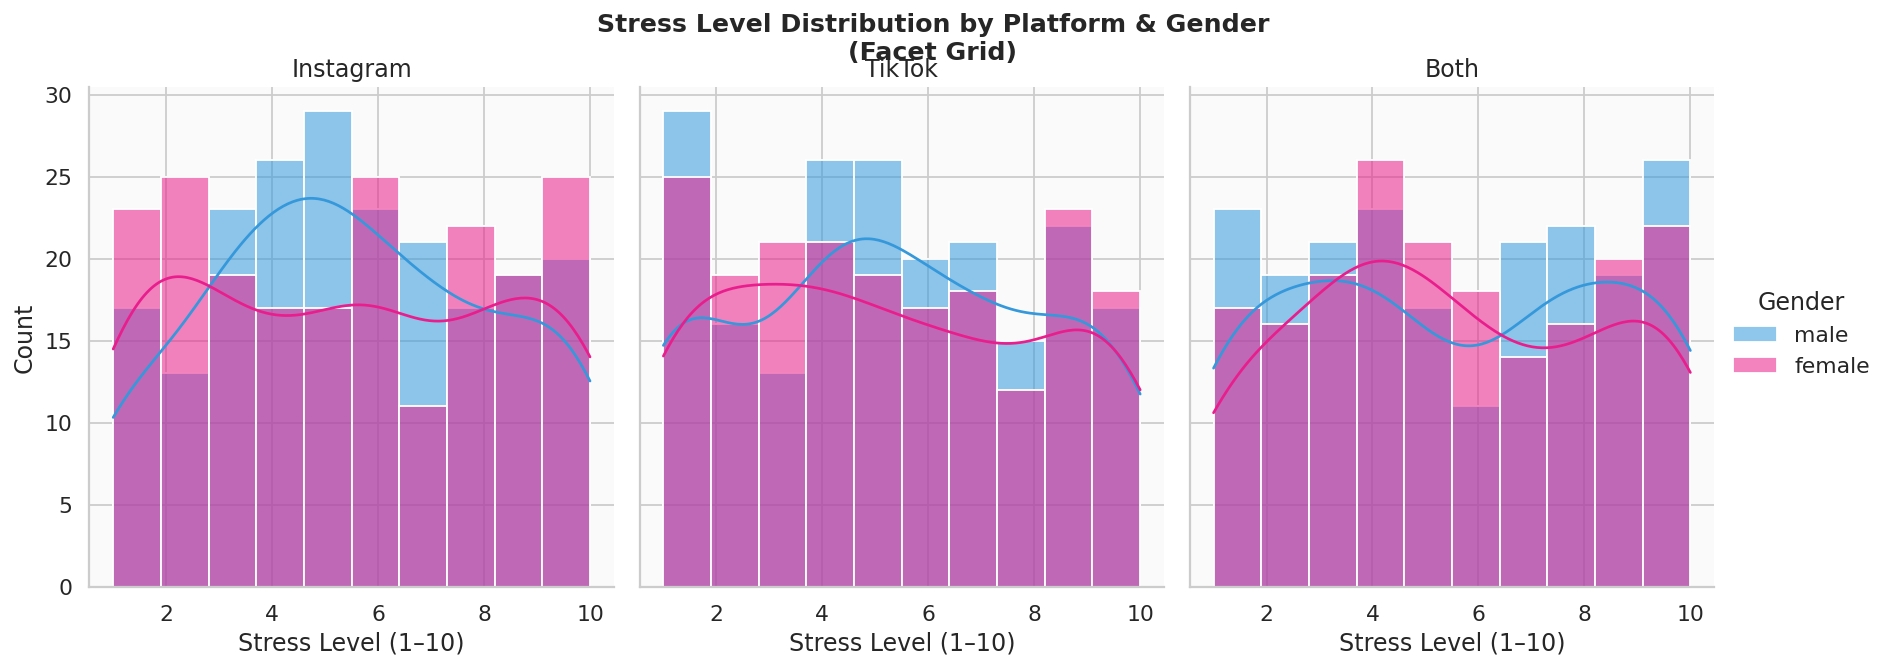

In [17]:
# ── FacetGrid: Stress level by platform × gender ──────────────────────────────
g = sns.FacetGrid(df, col='platform_usage', hue='gender',
                  palette=PAL_GENDER, height=5, aspect=0.9,
                  col_order=['Instagram', 'TikTok', 'Both'])
g.map(sns.histplot, 'stress_level', bins=10, alpha=0.55, kde=True)
g.add_legend(title='Gender')
g.set_axis_labels('Stress Level (1–10)', 'Count')
g.set_titles(col_template='{col_name}')
g.figure.suptitle('Stress Level Distribution by Platform & Gender\n(Facet Grid)',
                   fontsize=14, fontweight='bold', y=1.03)
plt.show()

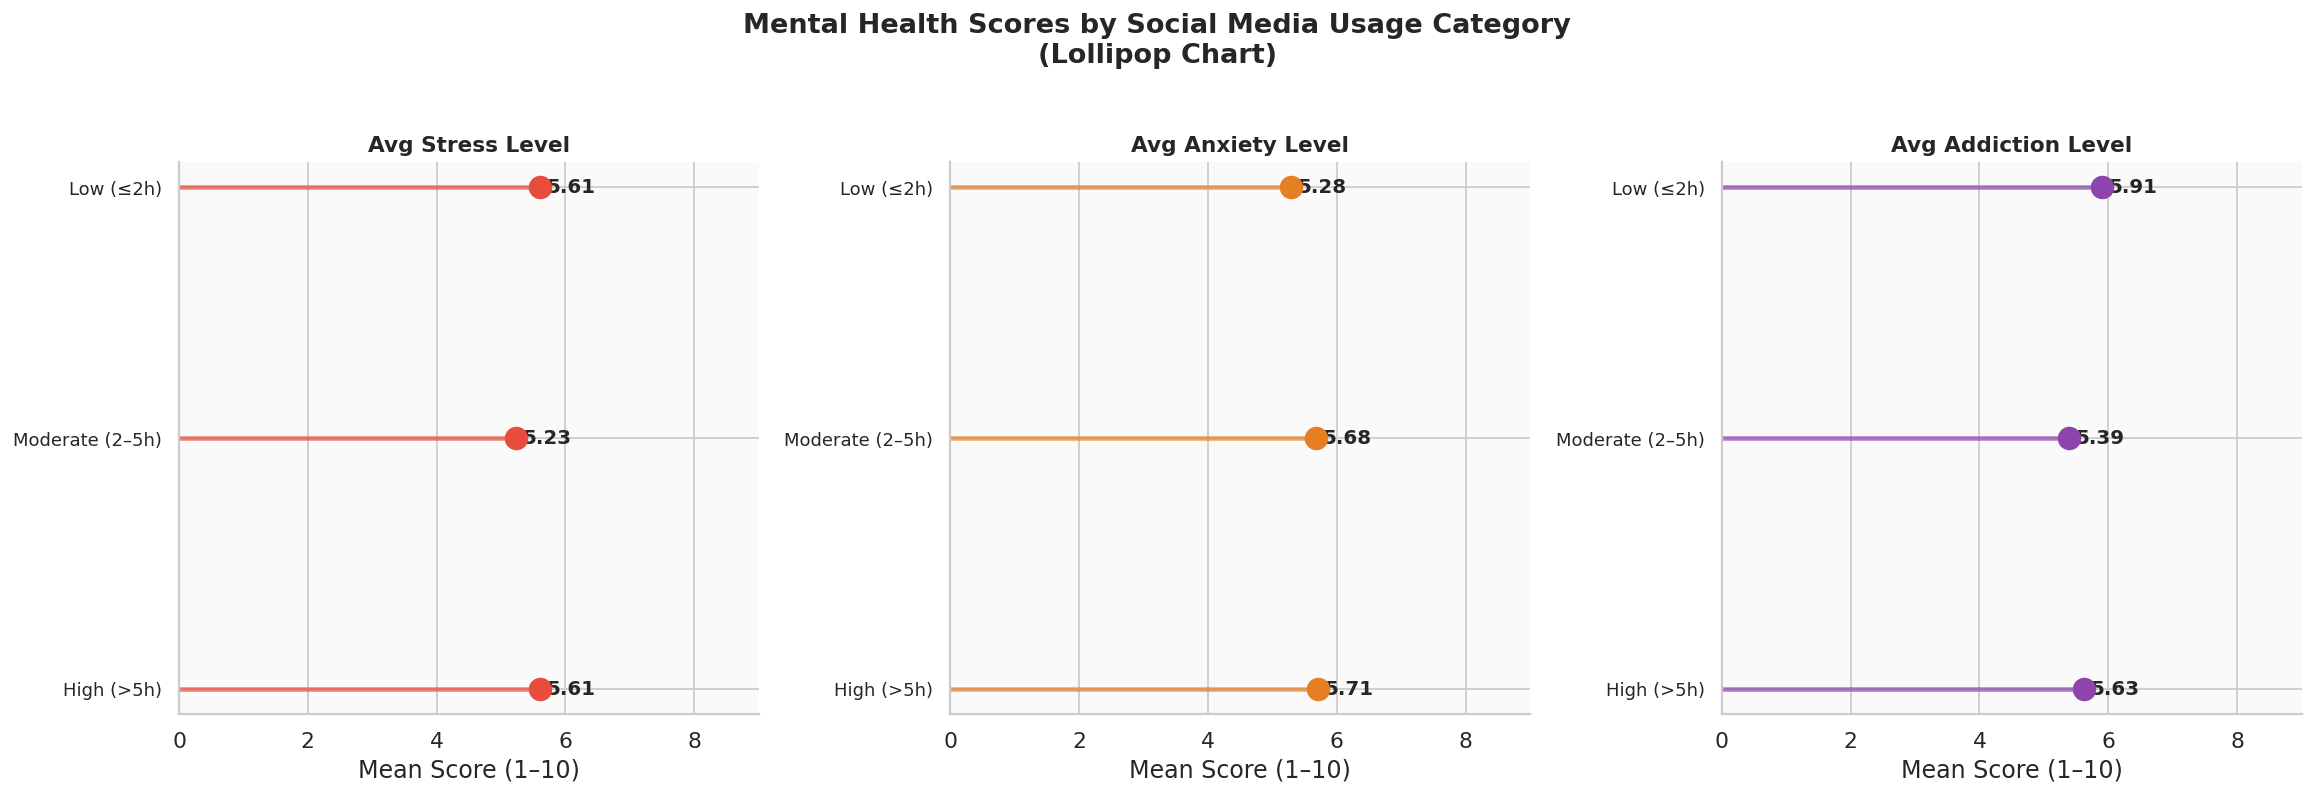

In [18]:
# ── Lollipop chart: Mean mental health scores by social media usage category ───
lollipop_data = df.groupby('social_media_cat', observed=True).agg(
    stress=('stress_level', 'mean'),
    anxiety=('anxiety_level', 'mean'),
    addiction=('addiction_level', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics_lollipop = [('stress','#e74c3c','Avg Stress Level'),
                    ('anxiety','#e67e22','Avg Anxiety Level'),
                    ('addiction','#8e44ad','Avg Addiction Level')]

for ax, (metric, color, title) in zip(axes, metrics_lollipop):
    cats = lollipop_data['social_media_cat'].astype(str)
    vals = lollipop_data[metric]
    ax.hlines(range(len(cats)), 0, vals, color=color, lw=2.5, alpha=0.7)
    ax.plot(vals, range(len(cats)), 'o', color=color, markersize=12, zorder=5)
    for i, val in enumerate(vals):
        ax.text(val + 0.1, i, f'{val:.2f}', va='center', fontsize=11, fontweight='bold')
    ax.set_yticks(range(len(cats)))
    ax.set_yticklabels(cats, fontsize=10)
    ax.set_xlabel('Mean Score (1–10)')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_xlim(0, 9)
    ax.invert_yaxis()

plt.suptitle('Mental Health Scores by Social Media Usage Category\n(Lollipop Chart)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

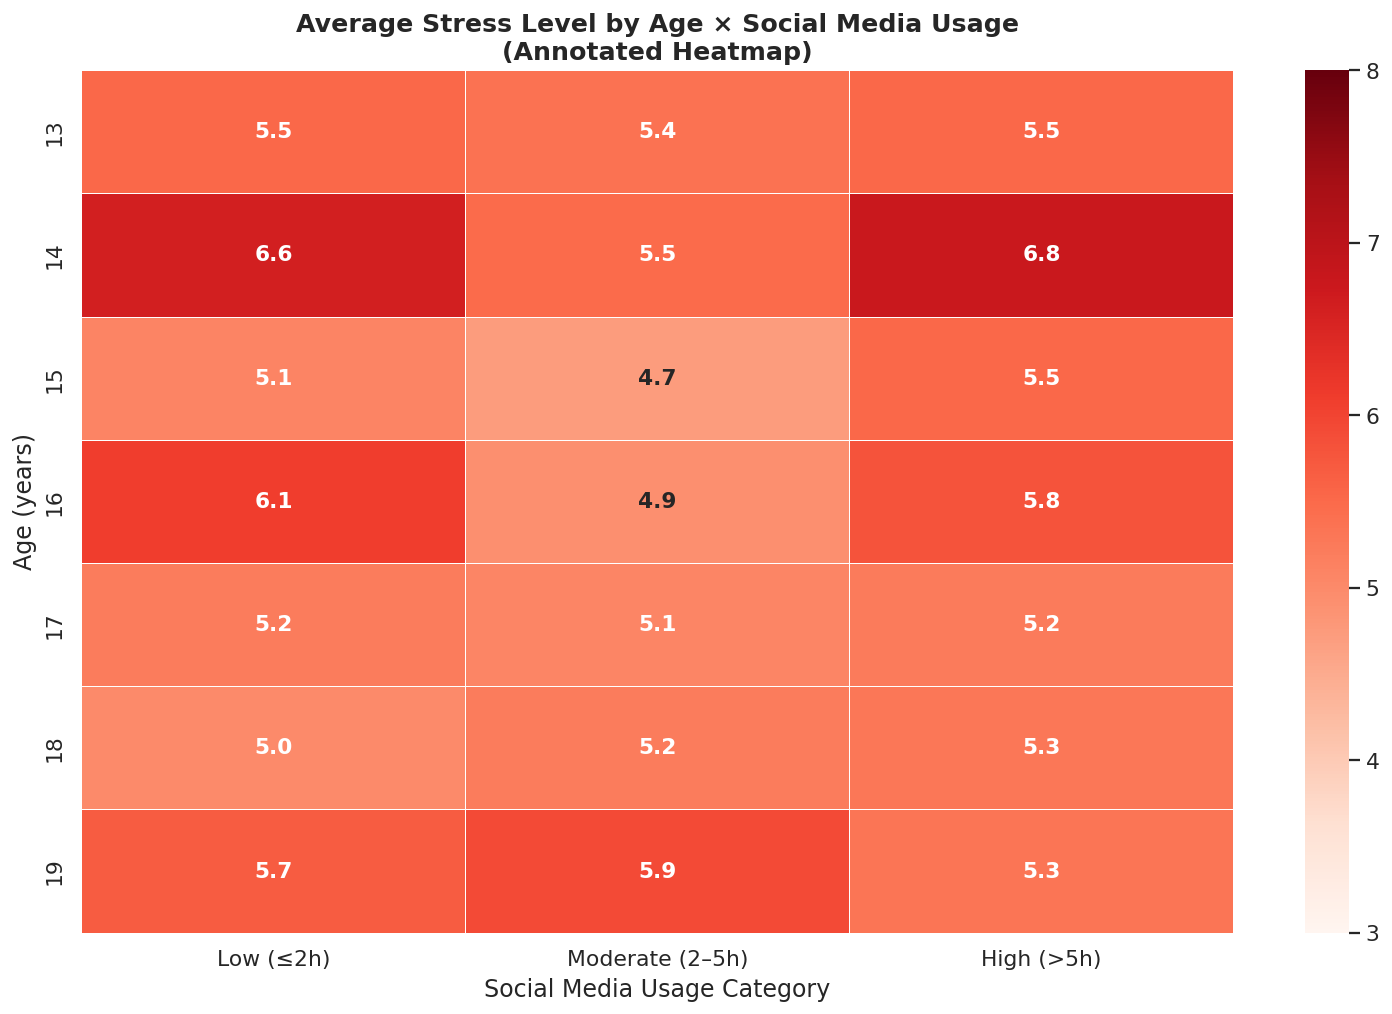

In [19]:
# ── Annotated heatmap: Avg stress by age × social media category ──────────────
pivot_stress = df.pivot_table(
    values='stress_level',
    index='age',
    columns='social_media_cat',
    aggfunc='mean',
    observed=True
)[['Low (≤2h)', 'Moderate (2–5h)', 'High (>5h)']]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_stress, annot=True, fmt='.1f', cmap='Reds',
            linewidths=0.5, ax=ax, vmin=3, vmax=8,
            annot_kws={'size': 12, 'weight': 'bold'})
ax.set_title('Average Stress Level by Age × Social Media Usage\n(Annotated Heatmap)',
             fontweight='bold', fontsize=14)
ax.set_xlabel('Social Media Usage Category')
ax.set_ylabel('Age (years)')
plt.tight_layout()
plt.show()

---
<a id='10'></a>
## 10 — Key Insights Summary

In [20]:
# ── Final summary statistics table ────────────────────────────────────────────
summary = pd.DataFrame({
    'Metric': [
        'Total Teens', 'Age Range', 'Avg Social Media/day',
        'Avg Sleep/night', 'Avg Stress (1-10)', 'Avg Anxiety (1-10)',
        'Avg Addiction (1-10)', 'Depression Rate',
        'Most Used Platform', 'Most Common Social Interaction'
    ],
    'Value': [
        f"{len(df):,}",
        f"{df['age'].min()}–{df['age'].max()} years",
        f"{df['daily_social_media_hours'].mean():.2f} hours",
        f"{df['sleep_hours'].mean():.2f} hours",
        f"{df['stress_level'].mean():.2f}",
        f"{df['anxiety_level'].mean():.2f}",
        f"{df['addiction_level'].mean():.2f}",
        f"{df['depression_label'].mean()*100:.1f}%",
        df['platform_usage'].mode()[0],
        df['social_interaction_level'].mode()[0]
    ]
})

print('='*50)
print('      TEEN MENTAL HEALTH — KEY FINDINGS')
print('='*50)
print(summary.to_string(index=False))
print('='*50)

      TEEN MENTAL HEALTH — KEY FINDINGS
                        Metric       Value
                   Total Teens       1,200
                     Age Range 13–19 years
          Avg Social Media/day  4.54 hours
               Avg Sleep/night  6.45 hours
             Avg Stress (1-10)        5.45
            Avg Anxiety (1-10)        5.64
          Avg Addiction (1-10)        5.57
               Depression Rate        2.6%
            Most Used Platform   Instagram
Most Common Social Interaction      medium


In [21]:
# ── Top correlations with mental health metrics ───────────────────────────────
print('\n📊 Top correlations with STRESS LEVEL:')
print(df[num_cols].corr()['stress_level'].drop('stress_level').sort_values(key=abs, ascending=False).head(5).to_string())

print('\n📊 Top correlations with DEPRESSION LABEL:')
print(df[num_cols].corr()['depression_label'].drop('depression_label').sort_values(key=abs, ascending=False).head(5).to_string())

print('\n📊 Top correlations with ANXIETY LEVEL:')
print(df[num_cols].corr()['anxiety_level'].drop('anxiety_level').sort_values(key=abs, ascending=False).head(5).to_string())


📊 Top correlations with STRESS LEVEL:
mental_health_score         0.585165
depression_label            0.170474
daily_social_media_hours    0.030698
anxiety_level               0.015811
physical_activity           0.012159

📊 Top correlations with DEPRESSION LABEL:
sleep_hours                -0.190630
mental_health_score         0.186638
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566

📊 Top correlations with ANXIETY LEVEL:
mental_health_score         0.594177
depression_label            0.169566
academic_performance       -0.064379
addiction_level             0.031154
daily_social_media_hours    0.027835


---

##  Visualization Recommendation Summary

| # | Visualization | Used For | Why Appropriate |
|---|---|---|---|
| 1 | **Histogram + KDE** | Social media hours distribution | Shows shape, skew, and gender overlap clearly |
| 2 | **Donut / Pie Chart** | Gender split | Best for proportions with 2 categories |
| 3 | **Grouped Bar Chart** | Age group × gender, mental scores | Side-by-side comparison across categories |
| 4 | **Stacked Bar Chart** | Platform by age group (%) | Shows part-to-whole relationships |
| 5 | **Violin Plot** | Social media hours by platform | Shows full distribution shape + quartiles |
| 6 | **Strip Plot** | Social media vs interaction level | Shows all data points without aggregation loss |
| 7 | **Box Plot** | Sleep by age/gender, feature vs depression | Reveals median, IQR, and outliers |
| 8 | **Scatter + Regression** | Screen time vs sleep, activity vs academics | Shows linear trend direction and strength |
| 9 | **Heatmap (pivot)** | Sleep by platform × interaction; stress by age | Encodes two categorical + one numerical dimension |
| 10 | **KDE / Ridge Plot** | Stress/anxiety/addiction by gender | Compares continuous distributions cleanly |
| 11 | **Radar Chart** | Mental scores by platform | Multi-dimensional comparison in one view |
| 12 | **Bubble Chart** | Social media vs stress (bubble=addiction) | Encodes 3 variables simultaneously |
| 13 | **Correlation Heatmap** | All numerical variables | Fast overview of all pairwise relationships |
| 14 | **Pair Plot** | Key mental health variables | Bivariate distributions + density diagonals |
| 15 | **Facet Grid** | Stress by platform × gender | Comparative distributions across two dimensions |
| 16 | **Lollipop Chart** | Mental scores by usage category | Clean ranked alternative to bar chart |
| 17 | **Annotated Heatmap** | Stress by age × social media hours | Two-way interaction patterns |

---
*Notebook by: Ibrahim Imran | Dataset: Teen Mental Health & Social Media 2026*